# Jakarta ISPU Classification

## Analisis Perbandingan Kinerja Model Ensemble dan Deep Learning untuk Klasifikasi ISPU Jakarta Menggunakan Explainable AI (SHAP)

Notebook ini mendokumentasikan proses eksperimen klasifikasi biner status Indeks Standar
Pencemar Udara (ISPU) DKI Jakarta periode 2020-2024. Target klasifikasi adalah
**Tidak Sehat+** (TIDAK SEHAT, SANGAT TIDAK SEHAT) versus **Bukan Tidak Sehat+**
(BAIK, SEDANG). Empat model dibandingkan: Random Forest, XGBoost, LSTM, dan GRU.
Interpretasi model dilakukan menggunakan SHAP.

---

### Catatan penting sebelum membaca hasil

Kolom polutan pada dataset ini (`pm25`, `pm10`, `so2`, `co`, `o3`, `no2`) berisi
**nilai sub-indeks ISPU**, bukan konsentrasi mentah dalam satuan mikrogram per meter kubik.
Kategori ISPU harian ditentukan dari nilai sub-indeks tertinggi melalui ambang batas tetap
(0-50 BAIK, 51-100 SEDANG, 101-200 TIDAK SEHAT, 201-300 SANGAT TIDAK SEHAT).

Konsekuensinya, target klasifikasi merupakan fungsi deterministik dari fitur input.
Mengeluarkan kolom `max` dan `critical` menghilangkan jawaban eksplisit, tetapi tidak
menghilangkan ketergantungan struktural tersebut.

Nilai performa tinggi pada model berbasis pohon **tidak boleh dibaca sebagai kemampuan
prediksi kualitas udara**, melainkan sebagai kemampuan model merekonstruksi aturan
penetapan ISPU yang telah diketahui. Pembahasan lengkap tersedia pada
[`docs/task-framing.md`](../docs/task-framing.md).

---

**Penulis:** Eriel Setiawan Dewantoro
**Program Studi:** Teknologi Informasi, Universitas Bina Sarana Informatika


## 1. Judul Eksperimen

Perbandingan model ensemble dan deep learning untuk klasifikasi status ISPU Jakarta menggunakan SHAP.


In [1]:
EXPERIMENT_TITLE = (
    "Analisis Perbandingan Kinerja Model Ensemble dan Deep Learning "
    "untuk Klasifikasi ISPU Jakarta Menggunakan Explainable AI (SHAP)"
)

print(EXPERIMENT_TITLE)


Analisis Perbandingan Kinerja Model Ensemble dan Deep Learning untuk Klasifikasi ISPU Jakarta Menggunakan Explainable AI (SHAP)


## 2. Import Library

Tahap ini menyiapkan pustaka Python yang digunakan untuk pengolahan data, visualisasi, pemodelan, evaluasi, dan interpretasi model. Backend deep learning yang digunakan adalah TensorFlow/Keras, sedangkan Random Forest menggunakan scikit-learn, XGBoost menggunakan pustaka XGBoost, dan interpretasi model menggunakan SHAP.

Jika notebook dijalankan di Google Colab, pustaka utama akan dipasang terlebih dahulu melalui perintah instalasi pada cell ini. Output tahap ini tidak digunakan sebagai hasil penelitian, tetapi menjadi prasyarat agar seluruh proses berikutnya dapat dijalankan secara berurutan.


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    %pip -q install pandas numpy scikit-learn xgboost tensorflow shap matplotlib seaborn

import os
import random
import warnings
import zipfile
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import shap

tf.get_logger().setLevel("ERROR")
warnings.filterwarnings("ignore")


## 3. Konfigurasi Eksperimen

Tahap ini menetapkan konfigurasi eksperimen yang digunakan secara konsisten di seluruh notebook. Konfigurasi meliputi periode penelitian 1 Januari 2020 sampai 31 Desember 2024, ukuran *sliding window* 14 hari untuk LSTM dan GRU, direktori output, daftar kolom polutan, kategori target, serta nama tampilan fitur.

Seluruh keputusan teknis, seperti periode penelitian, target biner, fitur model, dan skema sequence, ditetapkan pada bagian ini sebelum proses pengolahan data dilakukan sehingga eksperimen dapat ditelusuri ulang.


In [3]:
RANDOM_STATE = 42
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"
WINDOW_SIZE = 14

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

OUTPUT_DIR = Path("output")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

DATASET_FILENAME = "ispu_dki_all.csv"
DATASET_CANDIDATES = [
    Path(DATASET_FILENAME),
    Path("dataset") / DATASET_FILENAME,
    Path("/content") / DATASET_FILENAME,
    Path("/content/dataset") / DATASET_FILENAME,
]

pollutant_cols = ["pm25", "pm10", "so2", "co", "o3", "no2"]
target_positive_categories = ["TIDAK SEHAT", "SANGAT TIDAK SEHAT"]
target_negative_categories = ["BAIK", "SEDANG"]
excluded_feature_cols = ["stasiun", "max", "critical", "categori", "target_tidak_sehat", "target_label"]

FEATURE_DISPLAY_NAMES = {
    "pm25": "PM2.5",
    "pm10": "PM10",
    "so2": "SO2",
    "co": "CO",
    "o3": "O3",
    "no2": "NO2",
    "tahun": "Tahun",
    "bulan": "Bulan",
    "hari_dalam_minggu": "Hari dalam Minggu",
    "is_weekend": "Indikator Akhir Pekan",
    "is_pasca_pandemi": "Indikator Pasca-Pandemi",
    "pm25_was_missing": "Indikator Missing PM2.5",
    "pm10_was_missing": "Indikator Missing PM10",
    "so2_was_missing": "Indikator Missing SO2",
    "co_was_missing": "Indikator Missing CO",
    "o3_was_missing": "Indikator Missing O3",
    "no2_was_missing": "Indikator Missing NO2",
}

def save_figure(fig, filename, dpi=300):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

def save_table(df, filename, index=False):
    path = TABLE_DIR / filename
    df.to_csv(path, index=index)
    return path

def clean_axes(ax, xlabel=None, ylabel=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    return ax

def add_bar_labels(ax, fmt="{:.0f}", padding=3):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding, fontsize=9)

def add_note(ax, note):
    ax.text(0, -0.18, note, transform=ax.transAxes, fontsize=10, va="top", ha="left", wrap=True)

def display_feature_name(name):
    return FEATURE_DISPLAY_NAMES.get(name, name)

def evaluate_binary_model(model_name, y_true, y_pred, y_proba):
    return {
        "Model": model_name,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

def create_sequences_with_dates(X_array, y_array, date_array, window_size=14):
    X_seq, y_seq, target_dates = [], [], []
    for i in range(window_size, len(X_array)):
        X_seq.append(X_array[i - window_size:i])
        y_seq.append(y_array[i])
        target_dates.append(date_array[i])
    return np.asarray(X_seq), np.asarray(y_seq), pd.to_datetime(pd.Series(target_dates))

def make_binary_class_weight(y_array):
    y_array = np.asarray(y_array)
    negative_count = np.sum(y_array == 0)
    positive_count = np.sum(y_array == 1)
    total_count = len(y_array)
    if negative_count == 0 or positive_count == 0:
        return None
    return {0: total_count / (2 * negative_count), 1: total_count / (2 * positive_count)}

def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=False),
        Dropout(0.25),
        Dense(32, activation="relu"),
        Dropout(0.15),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_gru_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=False),
        Dropout(0.25),
        Dense(32, activation="relu"),
        Dropout(0.15),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
    return model

def extract_positive_shap_values(shap_values_raw):
    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[1]
    else:
        val = shap_values_raw.values if hasattr(shap_values_raw, "values") else np.asarray(shap_values_raw)
        shap_values = val[:, :, 1] if val.ndim == 3 else val
    shap_values = np.asarray(shap_values)
    if shap_values.ndim != 2:
        raise ValueError(f"Dimensi SHAP tidak sesuai: {shap_values.shape}")
    return shap_values

def impute_pollutants(part_df, monthly_medians=None, global_medians=None, fit=False):
    work = part_df.copy().sort_values("tanggal").set_index("tanggal")
    for col in pollutant_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")
        work[col] = work[col].interpolate(method="time", limit=7, limit_direction="both")

    if fit:
        monthly_medians = {col: work.groupby(work.index.month)[col].median() for col in pollutant_cols}
        global_medians = {col: work[col].median() for col in pollutant_cols}

    for col in pollutant_cols:
        month_values = work.index.month.map(monthly_medians[col])
        work[col] = work[col].fillna(pd.Series(month_values, index=work.index))
        work[col] = work[col].fillna(global_medians[col])

    return work.reset_index(), monthly_medians, global_medians


## 4. Load Dataset

Tahap ini memuat dataset utama `ispu_dki_all.csv`. Input pada tahap ini adalah file CSV yang berisi data harian ISPU DKI Jakarta. Proses yang dilakukan meliputi pencarian file dataset, pembacaan data, dan konversi kolom tanggal ke format tanggal.

Output tahap ini berupa cuplikan baris awal dataset, jumlah baris dan kolom data mentah, serta rentang tanggal awal. Informasi ini menjadi gambaran umum dataset awal.


In [4]:
dataset_path = next((path for path in DATASET_CANDIDATES if path.exists()), None)

if dataset_path is None:
    if IN_COLAB:
        from google.colab import files
        uploaded = files.upload()
        if DATASET_FILENAME not in uploaded:
            raise FileNotFoundError(f"File {DATASET_FILENAME} belum ditemukan.")
        dataset_path = Path(DATASET_FILENAME)
    else:
        raise FileNotFoundError(
            "Dataset tidak ditemukan. Letakkan ispu_dki_all.csv di folder notebook atau di folder dataset/."
        )

raw_df = pd.read_csv(dataset_path)
raw_df["tanggal"] = pd.to_datetime(raw_df["tanggal"], errors="coerce")

display(raw_df.head(10))
print(f"Path dataset: {dataset_path}")
print(f"Jumlah baris data mentah: {raw_df.shape[0]:,}")
print(f"Jumlah kolom data mentah: {raw_df.shape[1]:,}")
print(f"Rentang tanggal data mentah: {raw_df['tanggal'].min().date()} sampai {raw_df['tanggal'].max().date()}")


,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK
5,2010-01-06,DKI1 (Bunderan HI),NaN,30.0,3.0,22.0,19.0,11.0,30.0,PM10,BAIK
6,2010-01-07,DKI1 (Bunderan HI),NaN,41.0,4.0,24.0,27.0,13.0,41.0,PM10,BAIK
7,2010-01-08,DKI1 (Bunderan HI),NaN,64.0,8.0,51.0,19.0,15.0,64.0,PM10,SEDANG
8,2010-01-09,DKI1 (Bunderan HI),NaN,55.0,5.0,39.0,23.0,16.0,55.0,PM10,SEDANG
9,2010-01-10,DKI1 (Bunderan HI),NaN,34.0,5.0,23.0,26.0,12.0,34.0,PM10,BAIK


Path dataset: ispu_dki_all.csv
Jumlah baris data mentah: 5,538
Jumlah kolom data mentah: 11
Rentang tanggal data mentah: 2010-01-01 sampai 2025-02-28


**Cara membaca output:** Tabel pertama menampilkan cuplikan data awal. Baris ringkasan di bawahnya menunjukkan lokasi dataset, jumlah baris, jumlah kolom, dan rentang tanggal. Output ini memastikan bahwa dataset yang digunakan adalah data awal 5.538 baris dan 11 kolom dengan rentang 1 Januari 2010 sampai 28 Februari 2025.


## 5. Data Understanding

Tahap ini dilakukan untuk memahami struktur awal dataset sebelum data diproses lebih lanjut. Input yang digunakan adalah dataset mentah yang telah dimuat pada tahap sebelumnya. Proses yang dilakukan meliputi validasi nama kolom, pemeriksaan jumlah baris dan kolom, rentang tanggal, jumlah stasiun, serta distribusi kategori ISPU asli pada periode penelitian.

Output tahap ini berupa tabel ringkasan struktur data dan grafik distribusi kategori ISPU asli. Cara membaca grafik distribusi adalah dengan melihat tinggi batang; batang yang lebih tinggi menunjukkan kategori ISPU yang lebih sering muncul pada periode 2020-2024.


,Informasi,Nilai
0,Jumlah baris data mentah,"5,538"
1,Jumlah kolom data mentah,11
2,Tanggal awal data mentah,2010-01-01
3,Tanggal akhir data mentah,2025-02-28
4,Jumlah stasiun unik,5


,Kategori ISPU,Jumlah Hari
0,SEDANG,1160
1,TIDAK SEHAT,609
2,BAIK,50
3,SANGAT TIDAK SEHAT,7
4,TIDAK ADA DATA,1


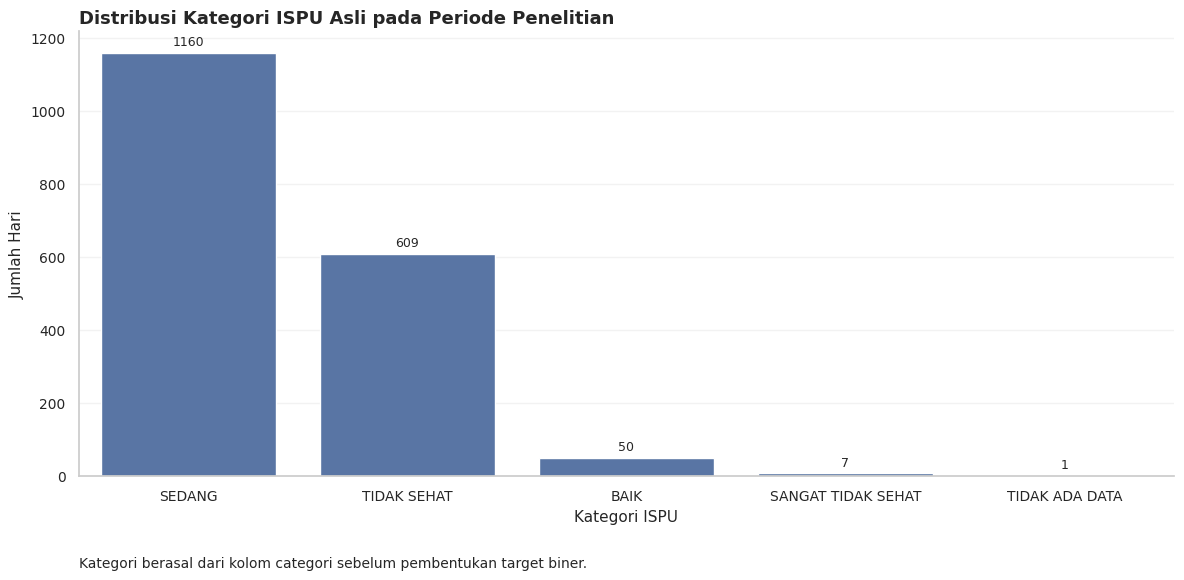

In [5]:
expected_columns = {"tanggal", "stasiun", "pm25", "pm10", "so2", "co", "o3", "no2", "max", "critical", "categori"}
missing_columns = expected_columns.difference(raw_df.columns)
if missing_columns:
    raise ValueError(f"Kolom dataset belum sesuai: {sorted(missing_columns)}")

data_structure = pd.DataFrame({
    "Informasi": [
        "Jumlah baris data mentah",
        "Jumlah kolom data mentah",
        "Tanggal awal data mentah",
        "Tanggal akhir data mentah",
        "Jumlah stasiun unik",
    ],
    "Nilai": [
        f"{raw_df.shape[0]:,}",
        f"{raw_df.shape[1]:,}",
        raw_df["tanggal"].min().date(),
        raw_df["tanggal"].max().date(),
        raw_df["stasiun"].nunique(dropna=True),
    ],
})
save_table(data_structure, "01_ringkasan_struktur_data.csv")
display(data_structure)

df_period_raw = (
    raw_df.loc[(raw_df["tanggal"] >= START_DATE) & (raw_df["tanggal"] <= END_DATE)]
    .copy()
    .sort_values("tanggal")
    .reset_index(drop=True)
)

category_period_counts = (
    df_period_raw["categori"]
    .value_counts(dropna=False)
    .rename_axis("Kategori ISPU")
    .reset_index(name="Jumlah Hari")
)
save_table(category_period_counts, "02_distribusi_kategori_ispu_asli.csv")
display(category_period_counts)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=category_period_counts, x="Kategori ISPU", y="Jumlah Hari", ax=ax)
ax.set_title("Distribusi Kategori ISPU Asli pada Periode Penelitian", loc="left", fontweight="bold")
clean_axes(ax, xlabel="Kategori ISPU", ylabel="Jumlah Hari")
add_bar_labels(ax)
add_note(ax, "Kategori berasal dari kolom categori sebelum pembentukan target biner.")
plt.xticks(rotation=0)
plt.tight_layout()
save_figure(fig, "01_distribusi_kategori_ispu_asli.png")
plt.show()


**Cara membaca output:** Tabel struktur data menunjukkan ukuran dan rentang dataset, sedangkan tabel distribusi kategori menunjukkan kategori ISPU asli sebelum target dibinerkan. Grafik kategori dibaca dari tinggi batang; kategori dengan batang lebih tinggi memiliki jumlah hari lebih banyak pada periode penelitian.


### Cara Membaca Visualisasi Distribusi Kategori

Visualisasi distribusi kategori ISPU asli menunjukkan frekuensi kemunculan kategori sebelum target penelitian dibinerkan. Kategori BAIK, SEDANG, TIDAK SEHAT, SANGAT TIDAK SEHAT, dan TIDAK ADA DATA ditampilkan sebagai bagian dari tahap *data understanding*. Grafik ini belum menunjukkan hasil model, melainkan kondisi awal data yang menjadi dasar pembentukan target pada tahap berikutnya.


## 6. Data Cleaning dan Seleksi Periode

Tahap ini membatasi data sesuai periode penelitian dan membersihkan kategori yang tidak valid untuk pemodelan. Input tahap ini adalah dataset awal yang sudah diperiksa strukturnya. Proses yang dilakukan meliputi seleksi periode 1 Januari 2020 sampai 31 Desember 2024 dan pengeluaran satu baris berkategori TIDAK ADA DATA.

Output tahap ini berupa ringkasan jumlah observasi: dataset awal 5.538 baris, hasil filter periode 2020-2024 sebanyak 1.827 observasi, dan data final pemodelan sebanyak 1.826 observasi. Ringkasan ini menjadi dasar data penelitian.


In [6]:
df_period = df_period_raw.copy()
df_period = df_period.sort_values("tanggal").reset_index(drop=True)

analysis_df = df_period.loc[df_period["categori"] != "TIDAK ADA DATA"].copy()
analysis_df = analysis_df.reset_index(drop=True)

period_summary = pd.DataFrame({
    "Informasi": [
        "Tanggal awal penelitian",
        "Tanggal akhir penelitian",
        "Jumlah observasi periode 2020-2024",
        "Jumlah observasi valid untuk pemodelan",
        "Kategori yang dikeluarkan",
    ],
    "Nilai": [
        df_period["tanggal"].min().date(),
        df_period["tanggal"].max().date(),
        f"{len(df_period):,}",
        f"{len(analysis_df):,}",
        "TIDAK ADA DATA",
    ],
})
save_table(period_summary, "03_ringkasan_seleksi_periode.csv")
display(period_summary)

assert df_period["tanggal"].min() == pd.Timestamp(START_DATE)
assert df_period["tanggal"].max() == pd.Timestamp(END_DATE)
assert "TIDAK ADA DATA" not in analysis_df["categori"].unique()


,Informasi,Nilai
0,Tanggal awal penelitian,2020-01-01
1,Tanggal akhir penelitian,2024-12-31
2,Jumlah observasi periode 2020-2024,"1,827"
3,Jumlah observasi valid untuk pemodelan,"1,826"
4,Kategori yang dikeluarkan,TIDAK ADA DATA


**Cara membaca output:** Tabel seleksi periode menunjukkan perubahan data dari periode 2020-2024 menjadi data final pemodelan. Nilai 1.827 menunjukkan observasi setelah filter periode, sedangkan 1.826 menunjukkan data final setelah kategori TIDAK ADA DATA dikeluarkan.


## 7. Target Engineering

Tahap ini membentuk target klasifikasi biner berdasarkan kategori ISPU asli. Input tahap ini adalah data final 1.826 observasi setelah kategori TIDAK ADA DATA dikeluarkan. Proses yang dilakukan adalah memetakan kategori TIDAK SEHAT dan SANGAT TIDAK SEHAT menjadi kelas positif **Tidak Sehat+**, sedangkan BAIK dan SEDANG menjadi **Bukan Tidak Sehat+**.

Output tahap ini adalah variabel `target_tidak_sehat` sebagai target numerik dan `target_label` sebagai label deskriptif. Distribusi target digunakan untuk membaca keseimbangan kelas dan menjadi dasar evaluasi model.


,Target Klasifikasi,Jumlah Hari,Persentase
0,Bukan Tidak Sehat+,1210,66.27
1,Tidak Sehat+,616,33.73


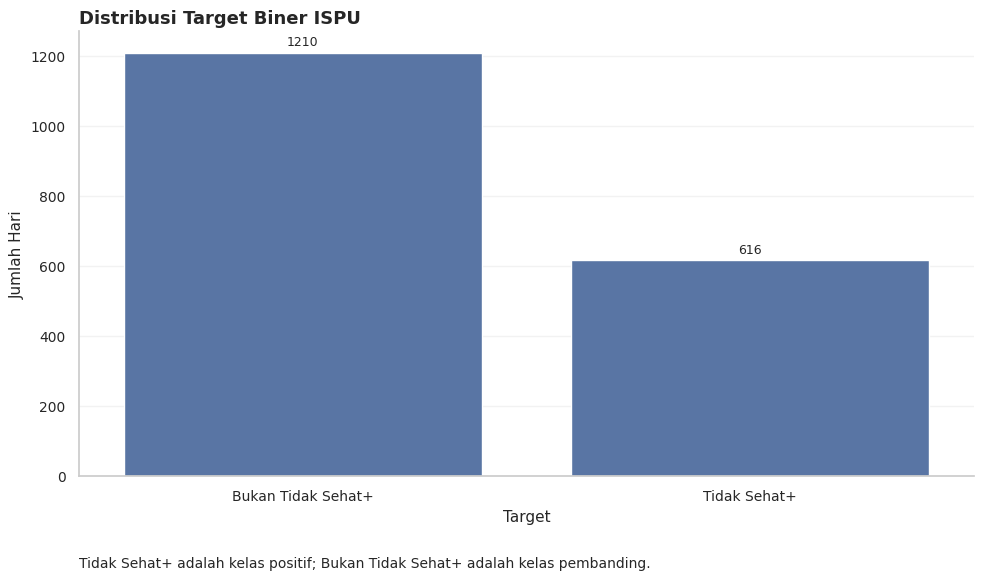

In [7]:
analysis_df["target_tidak_sehat"] = analysis_df["categori"].isin(target_positive_categories).astype(int)
analysis_df["target_label"] = analysis_df["target_tidak_sehat"].map({
    0: "Bukan Tidak Sehat+",
    1: "Tidak Sehat+",
})

target_counts = (
    analysis_df["target_label"]
    .value_counts()
    .rename_axis("Target Klasifikasi")
    .reset_index(name="Jumlah Hari")
)
target_counts["Persentase"] = (target_counts["Jumlah Hari"] / target_counts["Jumlah Hari"].sum() * 100).round(2)
save_table(target_counts, "04_distribusi_target_biner.csv")
display(target_counts)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=target_counts, x="Target Klasifikasi", y="Jumlah Hari", ax=ax)
ax.set_title("Distribusi Target Biner ISPU", loc="left", fontweight="bold")
clean_axes(ax, xlabel="Target", ylabel="Jumlah Hari")
add_bar_labels(ax)
add_note(ax, "Tidak Sehat+ adalah kelas positif; Bukan Tidak Sehat+ adalah kelas pembanding.")
plt.tight_layout()
save_figure(fig, "02_distribusi_target_biner.png")
plt.show()


**Cara membaca output:** Tabel distribusi target menunjukkan jumlah dan persentase setiap kelas target. Kelas Tidak Sehat+ menjadi kelas positif, sedangkan Bukan Tidak Sehat+ menjadi kelas pembanding. Grafik digunakan untuk melihat ketidakseimbangan kelas secara visual.


### Cara Membaca Visualisasi Distribusi Target

Grafik distribusi target biner menunjukkan perbandingan jumlah hari antara kelas Tidak Sehat+ dan Bukan Tidak Sehat+. Kelas Tidak Sehat+ merupakan kelas positif penelitian. Perbedaan tinggi batang menunjukkan bahwa target tidak sepenuhnya seimbang, sehingga evaluasi tidak hanya mengandalkan akurasi, tetapi menggunakan Precision, Recall, F1-Score, dan ROC-AUC.


## 8. Feature Engineering

Tahap ini membentuk fitur yang digunakan oleh model. Input tahap ini adalah data final yang telah memiliki target biner. Proses yang dilakukan mencakup konversi nilai polutan menjadi numerik, pembentukan indikator *missing values*, pembentukan fitur waktu, indikator akhir pekan, dan indikator pasca-pandemi.

Output tahap ini adalah daftar fitur final yang terdiri dari enam fitur polutan, fitur waktu, indikator akhir pekan, indikator pasca-pandemi, serta indikator *missing values*. Fitur hasil tahap ini digunakan pada model tabular dan menjadi dasar pembentukan sequence untuk LSTM dan GRU.


In [8]:
feature_df_raw = analysis_df.copy()

for col in pollutant_cols:
    feature_df_raw[col] = pd.to_numeric(feature_df_raw[col], errors="coerce")
    feature_df_raw[f"{col}_was_missing"] = feature_df_raw[col].isna().astype(int)

feature_df_raw["tahun"] = feature_df_raw["tanggal"].dt.year
feature_df_raw["bulan"] = feature_df_raw["tanggal"].dt.month
feature_df_raw["hari_dalam_minggu"] = feature_df_raw["tanggal"].dt.dayofweek
feature_df_raw["is_weekend"] = feature_df_raw["hari_dalam_minggu"].isin([5, 6]).astype(int)
feature_df_raw["is_pasca_pandemi"] = (feature_df_raw["tahun"] >= 2022).astype(int)

time_features = ["tahun", "bulan", "hari_dalam_minggu", "is_weekend", "is_pasca_pandemi"]
missing_indicator_features = [f"{col}_was_missing" for col in pollutant_cols]
feature_cols = pollutant_cols + time_features + missing_indicator_features

feature_preview_cols = ["tanggal"] + pollutant_cols + time_features + missing_indicator_features[:2]
display(feature_df_raw[feature_preview_cols].head(10))


,tanggal,pm25,pm10,so2,co,o3,no2,tahun,bulan,hari_dalam_minggu,is_weekend,is_pasca_pandemi,pm25_was_missing,pm10_was_missing
0,2020-01-01,NaN,35.0,13.0,18.0,46.0,NaN,2020,1,2,0,0,1,0
1,2020-01-02,NaN,22.0,15.0,24.0,102.0,7.0,2020,1,3,0,0,1,0
2,2020-01-03,NaN,44.0,17.0,21.0,63.0,7.0,2020,1,4,0,0,1,0
3,2020-01-04,NaN,40.0,18.0,19.0,85.0,9.0,2020,1,5,1,0,1,0
4,2020-01-05,NaN,37.0,21.0,18.0,62.0,5.0,2020,1,6,1,0,1,0
5,2020-01-06,NaN,58.0,18.0,28.0,64.0,9.0,2020,1,0,0,0,1,0
6,2020-01-07,NaN,36.0,18.0,39.0,66.0,9.0,2020,1,1,0,0,1,0
7,2020-01-08,NaN,49.0,21.0,22.0,70.0,10.0,2020,1,2,0,0,1,0
8,2020-01-09,NaN,82.0,38.0,31.0,30.0,6.0,2020,1,3,0,0,1,0
9,2020-01-10,NaN,25.0,17.0,17.0,47.0,7.0,2020,1,4,0,0,1,0


**Cara membaca output:** Cuplikan fitur memperlihatkan hasil awal pembentukan fitur polutan, fitur waktu, dan indikator nilai kosong. Tabel ini belum menunjukkan hasil model, tetapi menunjukkan bentuk data yang akan masuk ke tahap pemodelan.


## 9. Kamus Variabel

Tahap ini menjelaskan arti variabel teknis yang digunakan di dalam notebook agar pembaca tidak menafsirkan variabel tersebut sebagai variabel baru di luar metodologi penelitian. Input tahap ini adalah daftar variabel hasil pembentukan target dan fitur.

Output tahap ini berupa kamus variabel yang menjelaskan peran `target_tidak_sehat`, `target_label`, indikator waktu, indikator *missing values*, serta kolom yang dikecualikan. Kamus ini mendukung penjelasan metodologi dan pembacaan hasil.


In [9]:
variable_dictionary = pd.DataFrame([
    {"Variabel": "target_tidak_sehat", "Nama Tampilan": "Target Tidak Sehat+", "Peran": "Target numerik", "Penjelasan": "Bernilai 1 untuk TIDAK SEHAT dan SANGAT TIDAK SEHAT; bernilai 0 untuk BAIK dan SEDANG."},
    {"Variabel": "target_label", "Nama Tampilan": "Label Target", "Peran": "Label target", "Penjelasan": "Label teks Bukan Tidak Sehat+ dan Tidak Sehat+ untuk tabel serta grafik."},
    {"Variabel": "is_weekend", "Nama Tampilan": "Indikator Akhir Pekan", "Peran": "Fitur waktu", "Penjelasan": "Bernilai 1 untuk Sabtu atau Minggu; bernilai 0 untuk hari lain."},
    {"Variabel": "is_pasca_pandemi", "Nama Tampilan": "Indikator Pasca-Pandemi", "Peran": "Fitur waktu", "Penjelasan": "Bernilai 1 untuk tahun 2022-2024 dan 0 untuk tahun 2020-2021."},
    {"Variabel": "tahun", "Nama Tampilan": "Tahun", "Peran": "Fitur waktu", "Penjelasan": "Menunjukkan tahun observasi harian."},
    {"Variabel": "bulan", "Nama Tampilan": "Bulan", "Peran": "Fitur waktu", "Penjelasan": "Menunjukkan bulan observasi sebagai pendekatan konteks musiman."},
    {"Variabel": "hari_dalam_minggu", "Nama Tampilan": "Hari dalam Minggu", "Peran": "Fitur waktu", "Penjelasan": "Menunjukkan urutan hari dalam minggu dengan format numerik dari Pandas."},
    {"Variabel": "pm25_was_missing", "Nama Tampilan": "Indikator Missing PM2.5", "Peran": "Indikator missing", "Penjelasan": "Bernilai 1 jika PM2.5 awalnya kosong sebelum imputasi."},
    {"Variabel": "pm10_was_missing", "Nama Tampilan": "Indikator Missing PM10", "Peran": "Indikator missing", "Penjelasan": "Bernilai 1 jika PM10 awalnya kosong sebelum imputasi."},
    {"Variabel": "so2_was_missing", "Nama Tampilan": "Indikator Missing SO2", "Peran": "Indikator missing", "Penjelasan": "Bernilai 1 jika SO2 awalnya kosong sebelum imputasi."},
    {"Variabel": "co_was_missing", "Nama Tampilan": "Indikator Missing CO", "Peran": "Indikator missing", "Penjelasan": "Bernilai 1 jika CO awalnya kosong sebelum imputasi."},
    {"Variabel": "o3_was_missing", "Nama Tampilan": "Indikator Missing O3", "Peran": "Indikator missing", "Penjelasan": "Bernilai 1 jika O3 awalnya kosong sebelum imputasi."},
    {"Variabel": "no2_was_missing", "Nama Tampilan": "Indikator Missing NO2", "Peran": "Indikator missing", "Penjelasan": "Bernilai 1 jika NO2 awalnya kosong sebelum imputasi."},
    {"Variabel": "stasiun", "Nama Tampilan": "Stasiun Pemantauan", "Peran": "Dikecualikan", "Penjelasan": "Tidak digunakan sebagai fitur karena penelitian memosisikan data sebagai deret harian ISPU DKI Jakarta, bukan perbandingan antarstasiun pemantauan."},
    {"Variabel": "max", "Nama Tampilan": "Nilai Maksimum ISPU", "Peran": "Dikecualikan", "Penjelasan": "Tidak digunakan sebagai fitur karena terlalu dekat dengan pembentukan kategori ISPU."},
    {"Variabel": "critical", "Nama Tampilan": "Polutan Kritis", "Peran": "Dikecualikan", "Penjelasan": "Tidak digunakan sebagai fitur karena menunjukkan parameter penentu nilai ISPU harian."},
])

save_table(variable_dictionary, "05_kamus_variabel.csv")
display(variable_dictionary)


,Variabel,Nama Tampilan,Peran,Penjelasan
0,target_tidak_sehat,Target Tidak Sehat+,Target numerik,Bernilai 1 untuk TIDAK SEHAT dan SANGAT TIDAK ...
1,target_label,Label Target,Label target,Label teks Bukan Tidak Sehat+ dan Tidak Sehat+...
2,is_weekend,Indikator Akhir Pekan,Fitur waktu,Bernilai 1 untuk Sabtu atau Minggu; bernilai 0...
3,is_pasca_pandemi,Indikator Pasca-Pandemi,Fitur waktu,Bernilai 1 untuk tahun 2022-2024 dan 0 untuk t...
4,tahun,Tahun,Fitur waktu,Menunjukkan tahun observasi harian.
5,bulan,Bulan,Fitur waktu,Menunjukkan bulan observasi sebagai pendekatan...
6,hari_dalam_minggu,Hari dalam Minggu,Fitur waktu,Menunjukkan urutan hari dalam minggu dengan fo...
7,pm25_was_missing,Indikator Missing PM2.5,Indikator missing,Bernilai 1 jika PM2.5 awalnya kosong sebelum i...
8,pm10_was_missing,Indikator Missing PM10,Indikator missing,Bernilai 1 jika PM10 awalnya kosong sebelum im...
9,so2_was_missing,Indikator Missing SO2,Indikator missing,Bernilai 1 jika SO2 awalnya kosong sebelum imp...


**Cara membaca output:** Kamus variabel menjelaskan fungsi setiap variabel teknis di dalam notebook. Variabel target dan label target dijelaskan agar tidak disalahartikan sebagai fitur model.


## 10. Pencegahan Target Leakage dan Kolom yang Dikecualikan

Tahap ini memastikan bahwa kolom yang berpotensi menyebabkan *target leakage* tidak digunakan sebagai fitur model. Input tahap ini adalah daftar fitur final dan kolom awal dataset. Proses yang dilakukan adalah memeriksa apakah kolom `max`, `critical`, `categori`, `target_tidak_sehat`, `target_label`, dan `stasiun` masuk ke fitur model.

Output tahap ini berupa tabel keputusan kolom yang dikecualikan. Kolom `max` dan `critical` dikeluarkan karena terlalu dekat dengan pembentukan kategori ISPU, sedangkan `stasiun` dikeluarkan karena penelitian memosisikan data sebagai deret harian ISPU DKI Jakarta, bukan perbandingan antarstasiun.


In [10]:
leakage_check = pd.DataFrame({
    "Kolom": ["stasiun", "max", "critical", "categori", "target_tidak_sehat", "target_label"],
    "Digunakan sebagai Fitur": [col in feature_cols for col in ["stasiun", "max", "critical", "categori", "target_tidak_sehat", "target_label"]],
    "Keputusan": ["Dikecualikan"] * 6,
})

if leakage_check["Digunakan sebagai Fitur"].any():
    raise ValueError("Terdapat kolom yang tidak boleh masuk ke fitur model.")

save_table(leakage_check, "06_pencegahan_target_leakage.csv")
display(leakage_check)
print(f"Jumlah fitur sah yang digunakan: {len(feature_cols)}")


,Kolom,Digunakan sebagai Fitur,Keputusan
0,stasiun,False,Dikecualikan
1,max,False,Dikecualikan
2,critical,False,Dikecualikan
3,categori,False,Dikecualikan
4,target_tidak_sehat,False,Dikecualikan
5,target_label,False,Dikecualikan


Jumlah fitur sah yang digunakan: 17


**Cara membaca output:** Kolom yang bernilai `False` pada bagian penggunaan fitur menunjukkan bahwa kolom tersebut tidak masuk ke model. Jika ada kolom yang seharusnya dikecualikan tetapi bernilai `True`, notebook akan menghentikan proses untuk mencegah target leakage.


## 11. Split Data Kronologis

Tahap ini membagi data berdasarkan urutan waktu. Input tahap ini adalah data final hasil *feature engineering*. Proses yang dilakukan adalah menetapkan data 2020-2023 sebagai data latih dan data 2024 sebagai data uji.

Output tahap ini berupa ringkasan data latih sebanyak 1.460 observasi dan data uji sebanyak 366 observasi. Split kronologis digunakan karena data memiliki struktur waktu harian, sehingga data uji 2024 tidak digunakan dalam pelatihan model.


In [11]:
feature_df_raw = feature_df_raw.sort_values("tanggal").reset_index(drop=True)
test_start_date = pd.Timestamp("2024-01-01")

train_raw = feature_df_raw.loc[feature_df_raw["tanggal"] < test_start_date].copy()
test_raw = feature_df_raw.loc[feature_df_raw["tanggal"] >= test_start_date].copy()

y_train = train_raw["target_tidak_sehat"].copy()
y_test = test_raw["target_tidak_sehat"].copy()
train_dates = train_raw["tanggal"].copy()
test_dates = test_raw["tanggal"].copy()

split_summary = pd.DataFrame({
    "Subset": ["Data Latih", "Data Uji"],
    "Tanggal Awal": [train_dates.min().date(), test_dates.min().date()],
    "Tanggal Akhir": [train_dates.max().date(), test_dates.max().date()],
    "Jumlah Observasi": [len(train_raw), len(test_raw)],
    "Proporsi Tidak Sehat+": [round(y_train.mean(), 3), round(y_test.mean(), 3)],
})
save_table(split_summary, "07_split_data_kronologis.csv")
display(split_summary)


,Subset,Tanggal Awal,Tanggal Akhir,Jumlah Observasi,Proporsi Tidak Sehat+
0,Data Latih,2020-01-01,2023-12-31,1460,0.361
1,Data Uji,2024-01-01,2024-12-31,366,0.243


**Cara membaca output:** Tabel split menunjukkan periode, jumlah observasi, dan proporsi kelas positif untuk data latih dan data uji. Data uji tahun 2024 dipakai sebagai periode evaluasi generalisasi dan dasar SHAP data uji.


## 12. Missing Values dan Imputasi

Tahap ini memeriksa nilai kosong pada fitur polutan dan melakukan imputasi setelah data dibagi secara kronologis. Input tahap ini adalah data final 1.826 observasi. Proses yang dilakukan meliputi perhitungan jumlah dan persentase *missing values*, pemeriksaan pola *missing values* per tahun dan polutan, serta imputasi dengan prinsip train-only.

Output tahap ini berupa tabel *missing values*, grafik *missing values*, heatmap per tahun-polutan, dan validasi bahwa fitur polutan pada data latih serta data uji tidak lagi memiliki nilai kosong setelah imputasi. Catatan khusus diberikan pada PM2.5 tahun 2020 karena seluruh 366 hari pada tahun tersebut kosong sebelum imputasi.


,Kolom,Jumlah Missing,Persentase Missing
0,tanggal,0,0.00
1,pm25,369,20.21
2,pm10,200,10.95
3,so2,46,2.52
4,co,27,1.48
5,o3,23,1.26
6,no2,14,0.77


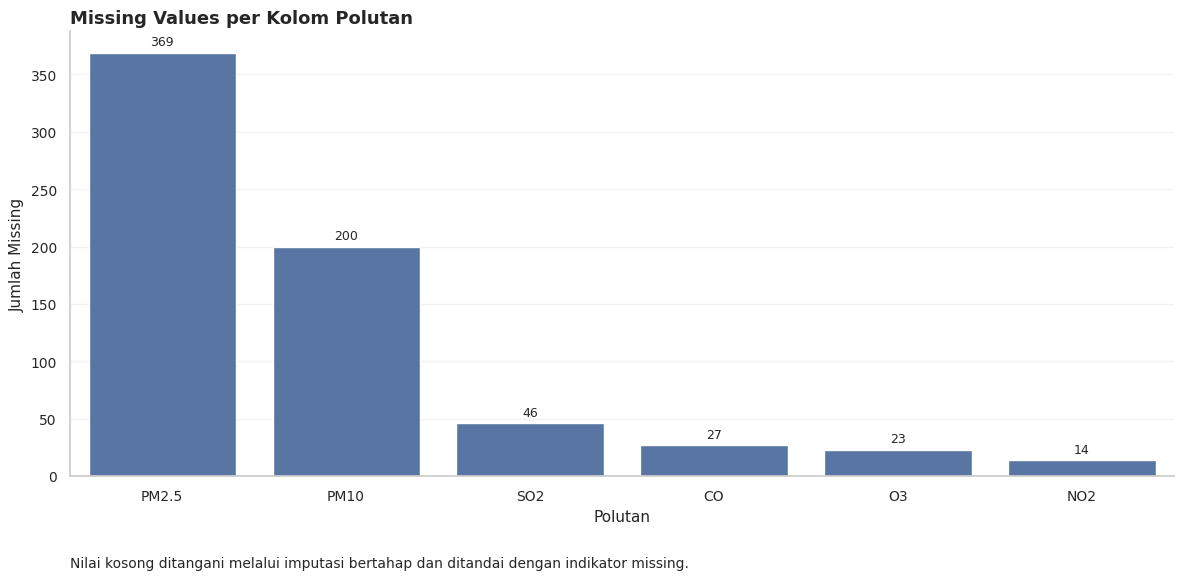

,PM2.5,PM10,SO2,CO,O3,NO2
Tahun,,,,,,
2020,366,1,29,7,2,4
2021,2,20,11,12,15,2
2022,0,0,0,0,0,0
2023,0,159,5,6,4,7
2024,1,20,1,2,2,1


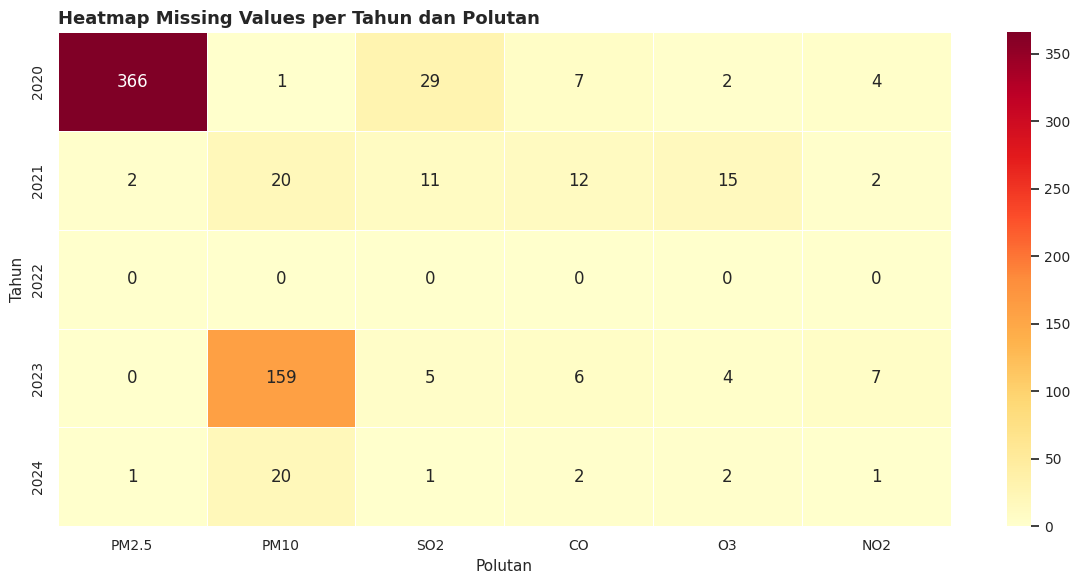

,Subset,Jumlah Missing Polutan Setelah Imputasi
0,Data Latih,0
1,Data Uji,0


Proporsi nilai PM2.5 yang kosong pada tahun 2020 adalah **100.0%**. Interpretasi kontribusi PM2.5 pada tahun tersebut perlu dibaca dengan batasan ini.

In [12]:
missing_summary = (
    feature_df_raw[["tanggal"] + pollutant_cols]
    .isna()
    .sum()
    .rename_axis("Kolom")
    .reset_index(name="Jumlah Missing")
)
missing_summary["Persentase Missing"] = (missing_summary["Jumlah Missing"] / len(feature_df_raw) * 100).round(2)
save_table(missing_summary, "08_missing_values_per_kolom.csv")
display(missing_summary)

missing_plot = missing_summary.loc[missing_summary["Kolom"].isin(pollutant_cols)].copy()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=missing_plot, x="Kolom", y="Jumlah Missing", ax=ax)
ax.set_title("Missing Values per Kolom Polutan", loc="left", fontweight="bold")
ax.set_xticklabels([display_feature_name(label.get_text()) for label in ax.get_xticklabels()])
clean_axes(ax, xlabel="Polutan", ylabel="Jumlah Missing")
add_bar_labels(ax)
add_note(ax, "Nilai kosong ditangani melalui imputasi bertahap dan ditandai dengan indikator missing.")
plt.tight_layout()
save_figure(fig, "03_missing_values_per_kolom.png")
plt.show()

missing_year_rows = []
for year, year_df in feature_df_raw.groupby("tahun"):
    row = {"Tahun": year}
    for col in pollutant_cols:
        row[display_feature_name(col)] = int(year_df[col].isna().sum())
    missing_year_rows.append(row)

missing_by_year = pd.DataFrame(missing_year_rows).set_index("Tahun")
save_table(missing_by_year.reset_index(), "09_missing_values_per_tahun_polutan.csv")
display(missing_by_year)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(missing_by_year, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Heatmap Missing Values per Tahun dan Polutan", loc="left", fontweight="bold")
ax.set_xlabel("Polutan")
ax.set_ylabel("Tahun")
plt.tight_layout()
save_figure(fig, "04_heatmap_missing_tahun_polutan.png")
plt.show()

train_imputed, monthly_medians, global_medians = impute_pollutants(train_raw, fit=True)
test_imputed, _, _ = impute_pollutants(test_raw, monthly_medians=monthly_medians, global_medians=global_medians, fit=False)

post_missing = pd.DataFrame({
    "Subset": ["Data Latih", "Data Uji"],
    "Jumlah Missing Polutan Setelah Imputasi": [
        int(train_imputed[pollutant_cols].isna().sum().sum()),
        int(test_imputed[pollutant_cols].isna().sum().sum()),
    ],
})
save_table(post_missing, "10_missing_setelah_imputasi.csv")
display(post_missing)

pm25_2020_missing_rate = feature_df_raw.loc[feature_df_raw["tahun"] == 2020, "pm25"].isna().mean()
display(Markdown(
    f"Proporsi nilai PM2.5 yang kosong pada tahun 2020 adalah **{pm25_2020_missing_rate:.1%}**. "
    "Interpretasi kontribusi PM2.5 pada tahun tersebut perlu dibaca dengan batasan ini."
))


**Cara membaca output:** Tabel dan grafik missing values menunjukkan kualitas data sebelum imputasi. Heatmap membantu melihat pola nilai kosong per tahun dan polutan. Validasi setelah imputasi harus menunjukkan nilai 0 pada data latih dan data uji.


### Cara Membaca Visualisasi Missing Values

Grafik batang menunjukkan jumlah nilai kosong pada masing-masing polutan, sedangkan heatmap menunjukkan sebaran nilai kosong per tahun dan polutan. Warna yang lebih pekat pada heatmap menunjukkan jumlah *missing values* yang lebih besar. Informasi ini digunakan untuk membatasi interpretasi, terutama pada PM2.5 tahun 2020 yang seluruh nilainya kosong sebelum imputasi.


## 13. Scaling dan Persiapan Data Model

Tahap ini menyiapkan matriks fitur dan target untuk pemodelan. Input tahap ini adalah data latih dan data uji yang telah diimputasi. Proses yang dilakukan meliputi pemisahan fitur (`X_train`, `X_test`) dan target (`y_train`, `y_test`), validasi bahwa tidak ada nilai kosong pada fitur, serta standardisasi fitur untuk LSTM dan GRU.

Output tahap ini berupa matriks fitur tabular, versi fitur yang telah distandardisasi untuk model sekuensial, serta tabel daftar 17 fitur model. Scaling digunakan terutama untuk LSTM dan GRU karena model jaringan saraf lebih sensitif terhadap skala fitur dibandingkan model berbasis pohon.


In [13]:
X_train = train_imputed[feature_cols].copy()
X_test = test_imputed[feature_cols].copy()
y_train = train_imputed["target_tidak_sehat"].copy()
y_test = test_imputed["target_tidak_sehat"].copy()
train_dates = train_imputed["tanggal"].copy()
test_dates = test_imputed["tanggal"].copy()

if X_train.isna().sum().sum() != 0 or X_test.isna().sum().sum() != 0:
    raise ValueError("Masih terdapat nilai kosong pada fitur model.")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

feature_table = pd.DataFrame({
    "Fitur": feature_cols,
    "Nama Tampilan": [display_feature_name(col) for col in feature_cols],
    "Kelompok": (
        ["Polutan"] * len(pollutant_cols)
        + ["Waktu"] * len(time_features)
        + ["Indikator Missing"] * len(missing_indicator_features)
    )
})
save_table(feature_table, "11_daftar_fitur_model.csv")
display(feature_table)


,Fitur,Nama Tampilan,Kelompok
0,pm25,PM2.5,Polutan
1,pm10,PM10,Polutan
2,so2,SO2,Polutan
3,co,CO,Polutan
4,o3,O3,Polutan
5,no2,NO2,Polutan
6,tahun,Tahun,Waktu
7,bulan,Bulan,Waktu
8,hari_dalam_minggu,Hari dalam Minggu,Waktu
9,is_weekend,Indikator Akhir Pekan,Waktu


**Cara membaca output:** Tabel fitur menunjukkan 17 fitur final yang digunakan dalam model. Fitur tersebut terdiri dari polutan, fitur waktu, indikator akhir pekan, indikator pasca-pandemi, dan indikator missing values.


## 14. Sequence Building untuk LSTM dan GRU

Tahap ini membentuk input sekuensial untuk LSTM dan GRU. Input yang digunakan adalah fitur data latih dan data uji yang sudah distandardisasi. Skema sequence yang digunakan adalah `X[i-window:i] → y[i]`, sehingga 14 hari sebelumnya digunakan untuk mengklasifikasikan status hari target.

Output tahap ini berupa jumlah sequence latih, sequence validasi, sequence uji, dan ukuran window. Data uji sequence tetap memiliki 366 target karena 14 hari terakhir data latih digunakan sebagai konteks awal untuk memprediksi hari pertama data uji 2024.


In [14]:
X_train_seq_all, y_train_seq_all, train_seq_dates = create_sequences_with_dates(
    X_train_scaled_df.values,
    y_train.values,
    train_dates.values,
    window_size=WINDOW_SIZE,
)

validation_index = int(len(X_train_seq_all) * 0.8)
X_train_seq_fit = X_train_seq_all[:validation_index]
y_train_seq_fit = y_train_seq_all[:validation_index]
X_val_seq = X_train_seq_all[validation_index:]
y_val_seq = y_train_seq_all[validation_index:]

X_context_for_test = np.vstack([X_train_scaled_df.tail(WINDOW_SIZE).values, X_test_scaled_df.values])
y_context_for_test = np.concatenate([y_train.tail(WINDOW_SIZE).values, y_test.values])
date_context_for_test = pd.concat([
    train_dates.tail(WINDOW_SIZE).reset_index(drop=True),
    test_dates.reset_index(drop=True),
]).reset_index(drop=True)

X_test_seq, y_test_seq, test_seq_dates = create_sequences_with_dates(
    X_context_for_test,
    y_context_for_test,
    date_context_for_test.values,
    window_size=WINDOW_SIZE,
)

if len(y_test_seq) != len(y_test):
    raise ValueError("Jumlah target uji LSTM/GRU belum sejajar dengan model tabular.")

if not pd.Series(test_seq_dates).reset_index(drop=True).equals(test_dates.reset_index(drop=True)):
    raise ValueError("Tanggal target LSTM/GRU belum sejajar dengan data uji tabular.")

sequence_summary = pd.DataFrame({
    "Komponen": ["Sequence latih", "Sequence validasi", "Sequence uji", "Panjang window"],
    "Nilai": [len(X_train_seq_fit), len(X_val_seq), len(X_test_seq), f"{WINDOW_SIZE} hari"],
})
save_table(sequence_summary, "12_ringkasan_sequence_lstm_gru.csv")
display(sequence_summary)


,Komponen,Nilai
0,Sequence latih,1156
1,Sequence validasi,290
2,Sequence uji,366
3,Panjang window,14 hari


**Cara membaca output:** Ringkasan sequence menunjukkan jumlah input sekuensial untuk LSTM dan GRU. Sequence latih dan validasi berasal dari data latih, sedangkan sequence uji disejajarkan dengan 366 target pada tahun 2024.


Catatan metodologis: Random Forest dan XGBoost menggunakan fitur tabular pada hari target, sedangkan LSTM dan GRU menggunakan konteks historis 14 hari sebelumnya untuk mengklasifikasikan hari target berikutnya. Oleh karena itu, perbandingan performa dibaca sebagai perbandingan dua pendekatan input yang berbeda, yaitu pendekatan tabular dan pendekatan sekuensial, bukan sebagai perbandingan input yang sepenuhnya identik.


## 15. Pemodelan Random Forest

Tahap ini melatih model Random Forest menggunakan fitur tabular pada hari target. Input yang digunakan adalah `X_train` dan `y_train` dari periode 2020-2023, kemudian model dievaluasi pada `X_test` dan `y_test` tahun 2024.

Output tahap ini berupa prediksi kelas, probabilitas kelas Tidak Sehat+, dan ringkasan metrik evaluasi Random Forest. Nilai akhir evaluasi digunakan pada perbandingan model di bagian Evaluasi Model dan pelaporan hasil.


In [15]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_result = evaluate_binary_model("Random Forest", y_test, rf_pred, rf_proba)
display(pd.DataFrame([rf_result]).round(4))


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9767,0.9438,0.96,0.9822


**Cara membaca output:** Tabel evaluasi satu baris menunjukkan hasil Random Forest pada data uji. Nilai ini akan digabungkan dengan model lain pada bagian evaluasi model.


## 16. Pemodelan XGBoost

Tahap ini melatih model XGBoost menggunakan fitur tabular yang sama dengan Random Forest. Input yang digunakan adalah data latih 2020-2023. Karena kelas target tidak seimbang, parameter `scale_pos_weight` dihitung dari rasio kelas negatif terhadap kelas positif pada data latih.

Output tahap ini berupa prediksi kelas, probabilitas kelas Tidak Sehat+, dan ringkasan metrik evaluasi XGBoost pada data uji 2024.


In [16]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_result = evaluate_binary_model("XGBoost", y_test, xgb_pred, xgb_proba)
display(pd.DataFrame([xgb_result]).round(4))


,Model,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.9767,0.9438,0.96,0.9705


**Cara membaca output:** Tabel evaluasi satu baris menunjukkan hasil XGBoost pada data uji. Parameter `scale_pos_weight` digunakan agar kelas positif Tidak Sehat+ tetap diperhatikan pada data yang tidak seimbang.


## 17. Pemodelan LSTM dan GRU

Tahap ini melatih model LSTM dan GRU menggunakan input sekuensial 14 hari. Input model bukan fitur tabular hari target, melainkan konteks historis `X[i-window:i]` untuk mengklasifikasikan `y[i]`. Backend yang digunakan adalah TensorFlow/Keras.

Output tahap ini berupa prediksi probabilitas dan prediksi kelas untuk LSTM serta GRU pada data uji 2024. Perbandingan performa dengan Random Forest dan XGBoost perlu dibaca sebagai perbandingan dua pendekatan input yang berbeda.


In [17]:
sequence_class_weight = make_binary_class_weight(y_train_seq_fit)
early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

tf.keras.backend.clear_session()
tf.random.set_seed(RANDOM_STATE)
lstm_model = build_lstm_model(input_shape=(X_train_seq_fit.shape[1], X_train_seq_fit.shape[2]))
lstm_history = lstm_model.fit(
    X_train_seq_fit,
    y_train_seq_fit,
    validation_data=(X_val_seq, y_val_seq),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=sequence_class_weight,
    shuffle=False,
    verbose=0,
)
lstm_proba = lstm_model.predict(X_test_seq, verbose=0).ravel()
lstm_pred = (lstm_proba >= 0.5).astype(int)

tf.keras.backend.clear_session()
tf.random.set_seed(RANDOM_STATE)
gru_model = build_gru_model(input_shape=(X_train_seq_fit.shape[1], X_train_seq_fit.shape[2]))
gru_history = gru_model.fit(
    X_train_seq_fit,
    y_train_seq_fit,
    validation_data=(X_val_seq, y_val_seq),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=sequence_class_weight,
    shuffle=False,
    verbose=0,
)
gru_proba = gru_model.predict(X_test_seq, verbose=0).ravel()
gru_pred = (gru_proba >= 0.5).astype(int)

lstm_result = evaluate_binary_model("LSTM", y_test_seq, lstm_pred, lstm_proba)
gru_result = evaluate_binary_model("GRU", y_test_seq, gru_pred, gru_proba)
display(pd.DataFrame([lstm_result, gru_result]).round(4))


,Model,Precision,Recall,F1-Score,ROC-AUC
0,LSTM,0.4639,0.5056,0.4839,0.6902
1,GRU,0.4507,0.3596,0.4000,0.7159


**Cara membaca output:** Tabel hasil LSTM dan GRU menunjukkan performa model deep learning berbasis sequence. Hasil ini dibaca dalam konteks input 14 hari sebelumnya, sehingga tidak identik dengan input tabular Random Forest dan XGBoost.


## 18. Evaluasi Model

Tahap ini membandingkan kinerja Random Forest, XGBoost, LSTM, dan GRU pada data uji tahun 2024. Input tahap ini adalah target aktual, prediksi kelas, dan probabilitas prediksi kelas Tidak Sehat+ dari setiap model.

Evaluasi dilakukan menggunakan Precision, Recall, F1-Score, dan ROC-AUC. Kelas positif pada evaluasi adalah Tidak Sehat+. Output pada bagian ini dipisahkan agar tabel dan setiap visual dapat dibaca tanpa perlu menggulir satu blok output yang panjang.


### 18.1 Tabel Evaluasi Empat Model

Cell berikut menyusun hasil evaluasi empat model dalam satu tabel ringkas. Tabel ini menjadi dasar angka evaluasi yang dilaporkan.


In [18]:
model_outputs = {
    "Random Forest": {"y_true": y_test.values, "y_pred": rf_pred, "y_proba": rf_proba},
    "XGBoost": {"y_true": y_test.values, "y_pred": xgb_pred, "y_proba": xgb_proba},
    "LSTM": {"y_true": y_test_seq, "y_pred": lstm_pred, "y_proba": lstm_proba},
    "GRU": {"y_true": y_test_seq, "y_pred": gru_pred, "y_proba": gru_proba},
}

results_df = pd.DataFrame([
    rf_result,
    xgb_result,
    lstm_result,
    gru_result,
]).sort_values(["F1-Score", "ROC-AUC", "Recall", "Precision"], ascending=False).reset_index(drop=True)

save_table(results_df.round(6), "13_evaluasi_empat_model.csv")
display(results_df.round(4))


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9767,0.9438,0.9600,0.9822
1,XGBoost,0.9767,0.9438,0.9600,0.9705
2,LSTM,0.4639,0.5056,0.4839,0.6902
3,GRU,0.4507,0.3596,0.4000,0.7159


**Cara membaca output:** setiap baris menunjukkan satu model, sedangkan setiap kolom menunjukkan metrik evaluasi pada data uji 2024. Nilai yang semakin mendekati 1 menunjukkan performa yang semakin baik. Tabel ini adalah hasil data uji, bukan hasil data latih.


### 18.2 Grafik Perbandingan Kinerja Model

Visualisasi berikut menampilkan metrik evaluasi dalam bentuk grafik batang agar perbandingan antar model lebih mudah dibaca.


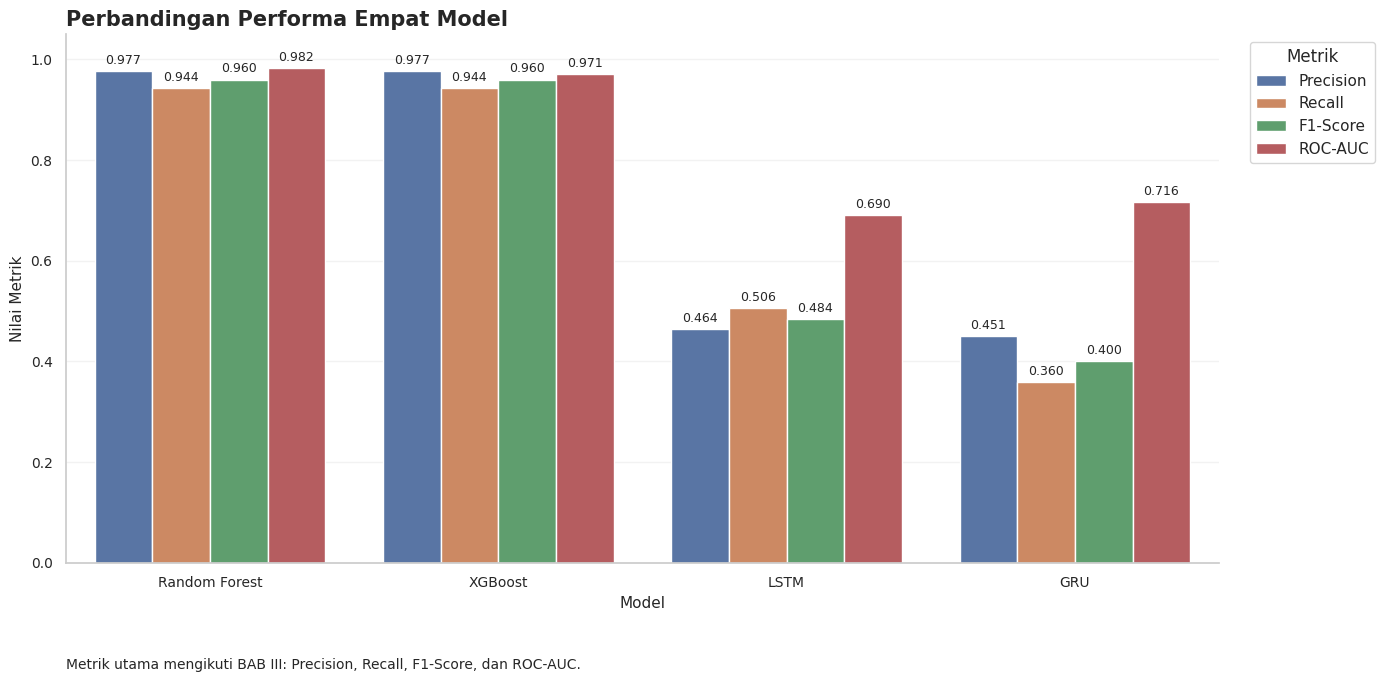

In [19]:
metric_plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1-Score", "ROC-AUC"],
    var_name="Metrik",
    value_name="Nilai",
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=metric_plot_df, x="Model", y="Nilai", hue="Metrik", ax=ax)
ax.set_title("Perbandingan Performa Empat Model", loc="left", fontweight="bold", fontsize=15)
clean_axes(ax, xlabel="Model", ylabel="Nilai Metrik")
add_bar_labels(ax, fmt="{:.3f}")
add_note(ax, "Metrik utama: Precision, Recall, F1-Score, dan ROC-AUC.")
ax.set_ylim(0, 1.05)
ax.legend(title="Metrik", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_figure(fig, "05_perbandingan_performa_empat_model.png")
plt.show()


**Cara membaca visual:** tinggi batang menunjukkan nilai metrik. Random Forest dan XGBoost memiliki F1-Score yang sama, sedangkan pemilihan model ensemble untuk SHAP mempertimbangkan ROC-AUC yang lebih tinggi pada Random Forest.


### 18.3 Confusion Matrix Random Forest

Confusion matrix berikut difokuskan pada Random Forest karena model ini digunakan sebagai model ensemble terpilih untuk interpretasi SHAP.


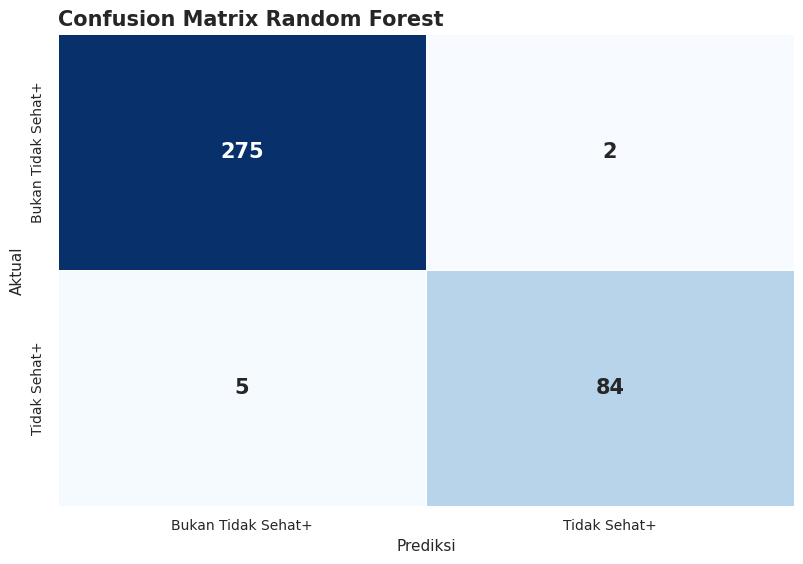

In [20]:
rf_cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(8.2, 5.8))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.7,
    linecolor="white",
    xticklabels=["Bukan Tidak Sehat+", "Tidak Sehat+"],
    yticklabels=["Bukan Tidak Sehat+", "Tidak Sehat+"],
    annot_kws={"fontsize": 15, "fontweight": "bold"},
    ax=ax,
)
ax.set_title("Confusion Matrix Random Forest", loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
plt.tight_layout()
save_figure(fig, "06_confusion_matrix_random_forest.png")
plt.show()


**Cara membaca visual:** nilai diagonal menunjukkan prediksi benar, sedangkan nilai di luar diagonal menunjukkan kesalahan klasifikasi. Kelas Tidak Sehat+ dibaca sebagai kelas positif penelitian.


### 18.4 ROC Curve Empat Model

Kurva ROC digunakan untuk membaca kemampuan pemisahan kelas pada berbagai threshold prediksi.


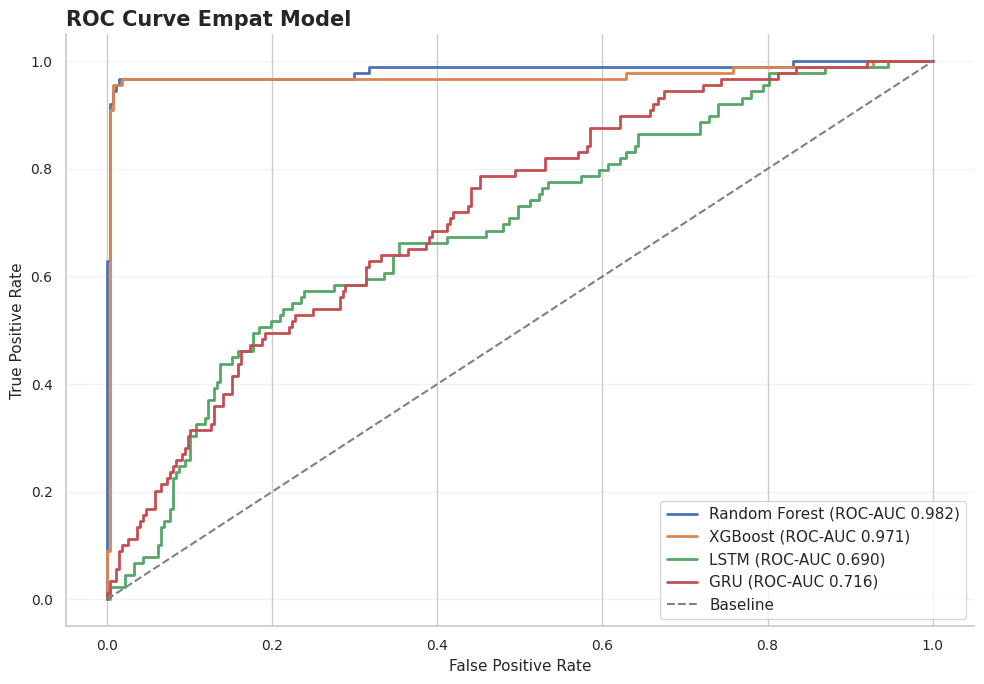

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))
for model_name, output in model_outputs.items():
    fpr, tpr, _ = roc_curve(output["y_true"], output["y_proba"])
    ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} (ROC-AUC {roc_auc_score(output['y_true'], output['y_proba']):.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Baseline")
ax.set_title("ROC Curve Empat Model", loc="left", fontweight="bold", fontsize=15)
clean_axes(ax, xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
save_figure(fig, "07_roc_curve_empat_model.png")
plt.show()


**Cara membaca visual:** kurva yang semakin dekat ke kiri atas menunjukkan kemampuan diskriminasi kelas yang lebih baik. Garis diagonal berfungsi sebagai pembanding acak.


### 18.5 Precision-Recall Curve Empat Model

Precision-Recall curve digunakan sebagai visualisasi pendukung untuk membaca hubungan antara ketepatan prediksi kelas positif dan kemampuan menemukan kelas Tidak Sehat+ aktual.


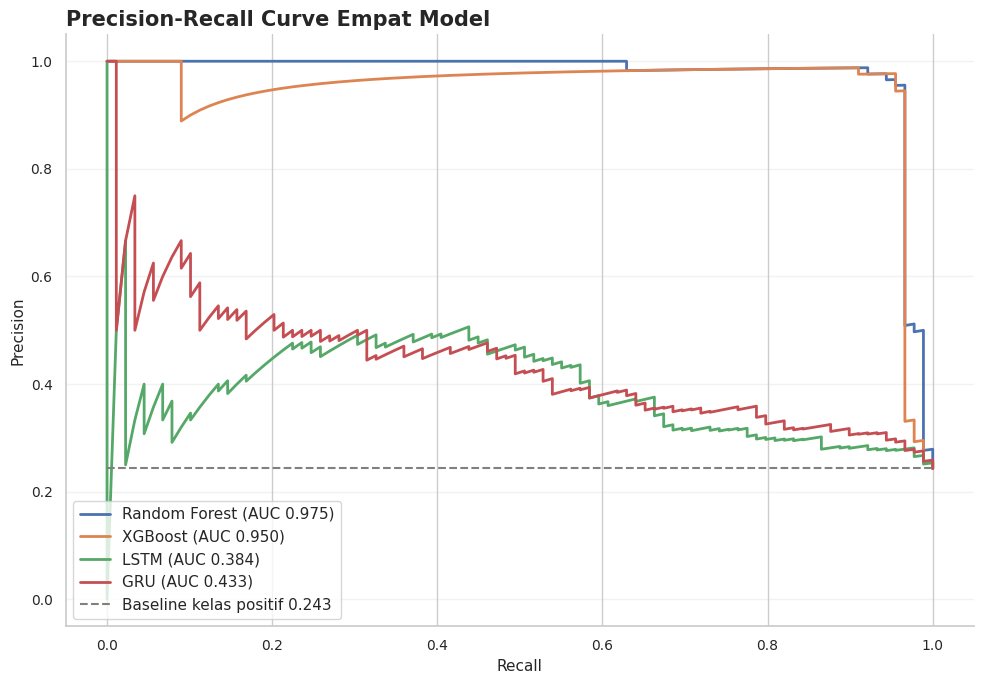

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))
for model_name, output in model_outputs.items():
    precision_vals, recall_vals, _ = precision_recall_curve(output["y_true"], output["y_proba"])
    pr_auc = auc(recall_vals, precision_vals)
    ax.plot(recall_vals, precision_vals, linewidth=2, label=f"{model_name} (AUC {pr_auc:.3f})")
baseline = y_test.mean()
ax.hlines(baseline, 0, 1, linestyle="--", color="gray", label=f"Baseline kelas positif {baseline:.3f}")
ax.set_title("Precision-Recall Curve Empat Model", loc="left", fontweight="bold", fontsize=15)
clean_axes(ax, xlabel="Recall", ylabel="Precision")
ax.legend(loc="lower left")
plt.tight_layout()
save_figure(fig, "08_precision_recall_curve_empat_model.png")
plt.show()


**Cara membaca visual:** kurva yang lebih tinggi menunjukkan kemampuan model menjaga precision dan recall secara lebih baik pada kelas Tidak Sehat+. Visual ini bersifat pendukung, sedangkan metrik utama tetap mengacu pada tabel evaluasi.


### 18.6 Ringkasan Model Terpilih

Cell berikut menyimpan nama model terbaik berdasarkan hasil evaluasi, kemudian menjelaskan dasar pemilihan model untuk tahap interpretasi.


In [23]:
best_model_name = results_df.iloc[0]["Model"]
display(Markdown(
    f"Model terbaik berdasarkan F1-Score dan ROC-AUC adalah **{best_model_name}**. "
    "Random Forest digunakan sebagai model ensemble terpilih untuk interpretasi SHAP karena F1-Score sama dengan XGBoost dan ROC-AUC lebih tinggi."
))


Model terbaik berdasarkan F1-Score dan ROC-AUC adalah **Random Forest**. Random Forest digunakan sebagai model ensemble terpilih untuk interpretasi SHAP karena F1-Score sama dengan XGBoost dan ROC-AUC lebih tinggi.

**Makna hasil:** pemilihan Random Forest tidak berarti XGBoost buruk. Keduanya memiliki performa sangat dekat, tetapi Random Forest dipilih untuk SHAP berdasarkan kombinasi hasil evaluasi, terutama ROC-AUC.


## 19. Interpretasi SHAP

Tahap ini membaca kontribusi fitur pada model berbasis ensemble yang dipilih setelah evaluasi. Input tahap ini adalah model ensemble terpilih, data uji tahun 2024, dan fitur final. SHAP digunakan untuk menjelaskan kontribusi fitur terhadap keputusan model, bukan untuk membuktikan hubungan sebab-akibat.

Output SHAP dipisahkan menjadi beberapa subbagian agar setiap tabel dan visual dapat dibaca secara langsung.


### 19.1 Persiapan Model dan Data SHAP

Cell berikut memilih model ensemble untuk SHAP dan menghitung nilai SHAP pada data uji 2024. Data uji 2024 digunakan karena periode tersebut tidak digunakan untuk melatih model.


In [24]:
ensemble_results_df = results_df.loc[results_df["Model"].isin(["Random Forest", "XGBoost"])].copy()
best_ensemble_name = ensemble_results_df.sort_values(["F1-Score", "ROC-AUC"], ascending=False).iloc[0]["Model"]
best_ensemble_model = rf_model if best_ensemble_name == "Random Forest" else xgb_model

X_test_shap = X_test.copy()
X_test_shap_display = X_test_shap.rename(columns=FEATURE_DISPLAY_NAMES)

explainer = shap.TreeExplainer(best_ensemble_model)
shap_values_raw = explainer.shap_values(X_test_shap)
shap_values_positive = extract_positive_shap_values(shap_values_raw)

if shap_values_positive.shape != X_test_shap.shape:
    raise ValueError("Ukuran SHAP tidak sesuai dengan ukuran data uji.")

display(Markdown(
    f"SHAP data uji dihitung pada model ensemble terpilih, yaitu **{best_ensemble_name}**, "
    f"dengan jumlah observasi data uji sebanyak **{len(X_test_shap):,}** hari."
))


SHAP data uji dihitung pada model ensemble terpilih, yaitu **Random Forest**, dengan jumlah observasi data uji sebanyak **366** hari.

**Cara membaca output:** output ini menunjukkan model yang dipakai untuk interpretasi SHAP dan jumlah observasi yang dijelaskan. Tahap ini belum menafsirkan fitur, tetapi menyiapkan nilai kontribusi fitur untuk tabel dan grafik berikutnya.


### 19.2 SHAP Feature Importance Data Uji 2024

Tabel berikut menampilkan mean absolute SHAP pada data uji 2024. Nilai ini menunjukkan kontribusi rata-rata absolut fitur terhadap keputusan model.


In [25]:
test_shap_importance = (
    pd.DataFrame({
        "Fitur": feature_cols,
        "Nama Tampilan": [display_feature_name(col) for col in feature_cols],
        "Mean Absolute SHAP": np.abs(shap_values_positive).mean(axis=0),
    })
    .sort_values("Mean Absolute SHAP", ascending=False)
    .reset_index(drop=True)
)
test_shap_importance["Peringkat"] = np.arange(1, len(test_shap_importance) + 1)
test_shap_importance = test_shap_importance[["Peringkat", "Fitur", "Nama Tampilan", "Mean Absolute SHAP"]]
save_table(test_shap_importance.round(6), "14_shap_importance_data_uji.csv")
display(test_shap_importance.round(6))


,Peringkat,Fitur,Nama Tampilan,Mean Absolute SHAP
0,1,pm25,PM2.5,0.323157
1,2,pm10,PM10,0.083515
2,3,o3,O3,0.047695
3,4,co,CO,0.026628
4,5,no2,NO2,0.023424
5,6,so2,SO2,0.013650
6,7,pm25_was_missing,Indikator Missing PM2.5,0.008758
7,8,bulan,Bulan,0.007862
8,9,tahun,Tahun,0.007825
9,10,pm10_was_missing,Indikator Missing PM10,0.005726


**Cara membaca output:** fitur dengan nilai mean absolute SHAP lebih besar memiliki kontribusi rata-rata lebih besar terhadap keputusan model. Nilai tersebut bukan persentase dan tidak menunjukkan hubungan kausal.


### 19.3 SHAP Summary Plot Data Uji 2024

Summary plot memperlihatkan arah dan sebaran kontribusi fitur pada data uji. Plot ini membantu membaca apakah nilai fitur tertentu cenderung mendorong prediksi ke arah Tidak Sehat+ atau Bukan Tidak Sehat+.


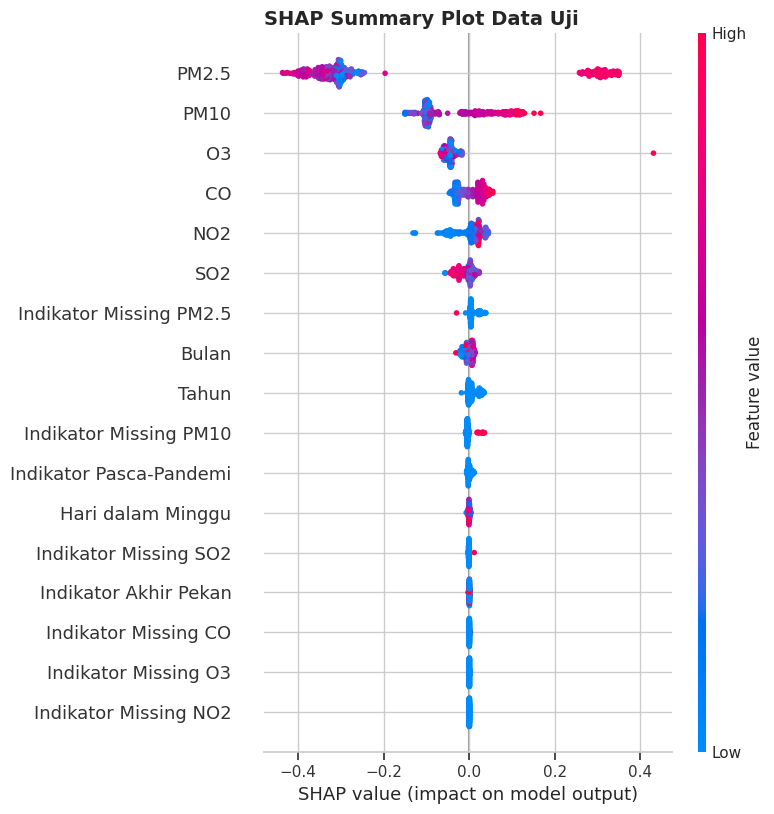

In [26]:
plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values_positive,
    X_test_shap_display,
    show=False,
    max_display=20,
)
fig = plt.gcf()
plt.title("SHAP Summary Plot Data Uji", loc="left", fontweight="bold", fontsize=14)
plt.tight_layout()
save_figure(fig, "09_shap_summary_data_uji.png")
plt.show()


**Cara membaca visual:** titik di sisi kanan mendorong prediksi ke arah Tidak Sehat+, sedangkan titik di sisi kiri mendorong prediksi ke arah Bukan Tidak Sehat+. Warna merah menunjukkan nilai fitur tinggi dan warna biru menunjukkan nilai fitur rendah.


### 19.4 Grafik SHAP Feature Importance Data Uji 2024

Grafik berikut menampilkan fitur dengan kontribusi rata-rata terbesar secara visual agar lebih mudah dibaca.


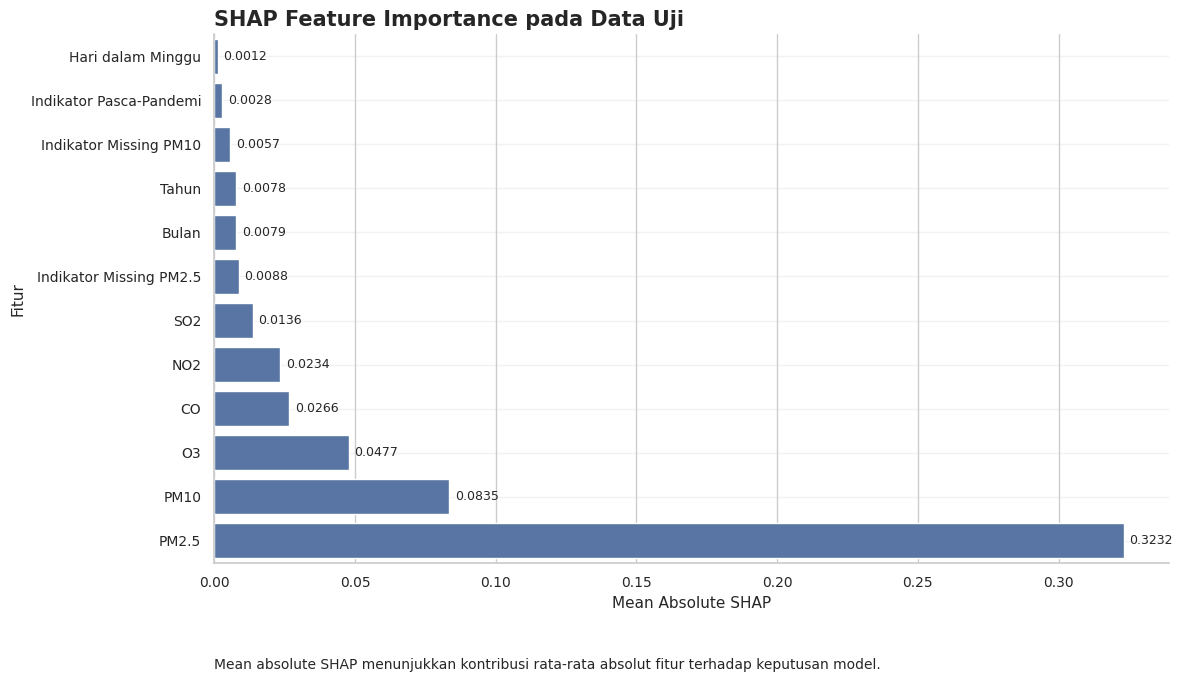

In [27]:
top_shap = test_shap_importance.head(12).sort_values("Mean Absolute SHAP", ascending=True)
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top_shap, x="Mean Absolute SHAP", y="Nama Tampilan", ax=ax)
ax.set_title("SHAP Feature Importance pada Data Uji", loc="left", fontweight="bold", fontsize=15)
clean_axes(ax, xlabel="Mean Absolute SHAP", ylabel="Fitur")
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=4, fontsize=9)
add_note(ax, "Mean absolute SHAP menunjukkan kontribusi rata-rata absolut fitur terhadap keputusan model.")
plt.tight_layout()
save_figure(fig, "10_shap_feature_importance_data_uji.png")
plt.show()


**Interpretasi singkat:** batang yang lebih panjang menunjukkan kontribusi rata-rata fitur yang lebih besar dalam keputusan model. Interpretasi tetap berbasis model dan tidak boleh dibaca sebagai bukti sebab-akibat.


### 19.5 SHAP Historis 2020-2024

SHAP historis digunakan sebagai diagnosis retrospektif pada data periode 2020-2024. Model diagnostik dilatih pada data periode 2020-2024 yang telah diimputasi, kemudian nilai SHAP dihitung untuk membaca kontribusi rata-rata polutan per tahun.


In [28]:
full_imputed, _, _ = impute_pollutants(feature_df_raw, fit=True)
X_full = full_imputed[feature_cols].copy()
y_full = full_imputed["target_tidak_sehat"].copy()

diagnostic_model = clone(best_ensemble_model)
diagnostic_model.fit(X_full, y_full)
historical_explainer = shap.TreeExplainer(diagnostic_model)
historical_shap_raw = historical_explainer.shap_values(X_full)
historical_shap_positive = extract_positive_shap_values(historical_shap_raw)

historical_abs_shap = pd.DataFrame(historical_shap_positive, columns=feature_cols).abs()
annual_pollutant_shap = (
    historical_abs_shap[pollutant_cols]
    .assign(Tahun=full_imputed["tahun"].values)
    .groupby("Tahun")
    .mean()
    .reset_index()
)
annual_pollutant_shap_display = annual_pollutant_shap.rename(columns={col: display_feature_name(col) for col in pollutant_cols})
save_table(annual_pollutant_shap_display.round(6), "15_shap_polutan_per_tahun.csv")
display(annual_pollutant_shap_display.round(6))


,Tahun,PM2.5,PM10,SO2,CO,O3,NO2
0,2020,0.147223,0.060376,0.019672,0.023260,0.178858,0.052844
1,2021,0.332115,0.073627,0.010863,0.022255,0.042590,0.024469
2,2022,0.344051,0.071245,0.009655,0.017406,0.044692,0.016474
3,2023,0.327718,0.066298,0.008432,0.028473,0.036214,0.021980
4,2024,0.325607,0.076996,0.013993,0.025886,0.046096,0.023611


**Cara membaca output:** setiap baris menunjukkan tahun, sedangkan setiap kolom polutan menunjukkan mean absolute SHAP tahunan. Nilai lebih besar menunjukkan kontribusi rata-rata yang lebih besar menurut model diagnostik historis.


### 19.6 Heatmap SHAP Historis 2020-2024

Heatmap berikut memvisualisasikan mean absolute SHAP historis agar pola tahunan per polutan lebih mudah dibaca.


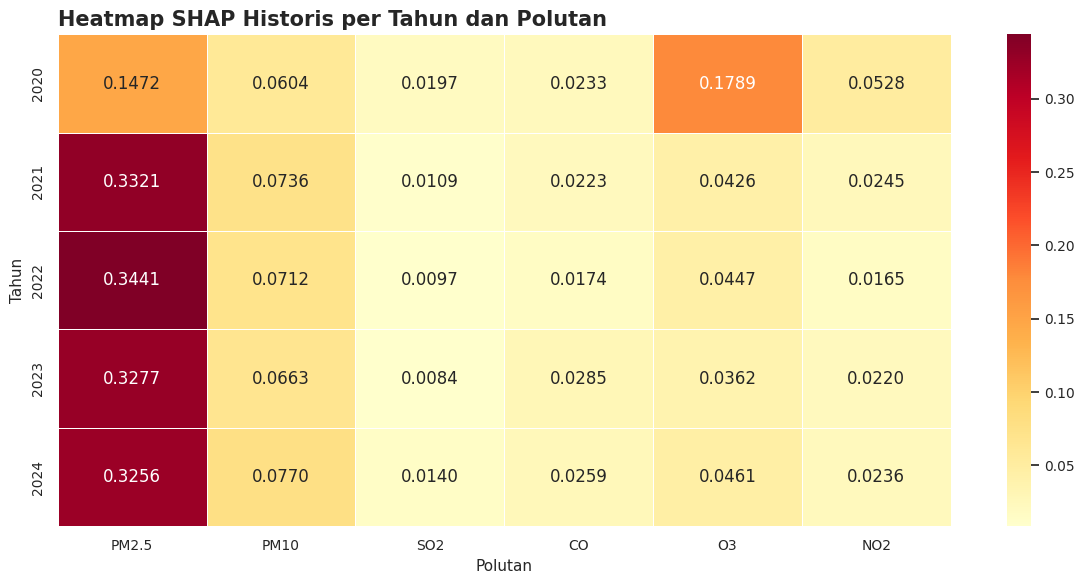

In [29]:
heatmap_df = annual_pollutant_shap_display.set_index("Tahun")
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".4f", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Heatmap SHAP Historis per Tahun dan Polutan", loc="left", fontweight="bold", fontsize=15)
ax.set_xlabel("Polutan")
ax.set_ylabel("Tahun")
plt.tight_layout()
save_figure(fig, "11_heatmap_shap_historis_tahun_polutan.png")
plt.show()


**Cara membaca visual:** warna yang lebih pekat menunjukkan mean absolute SHAP yang lebih besar. Interpretasi PM2.5 pada tahun 2020 perlu dibatasi karena seluruh 366 nilai PM2.5 pada tahun tersebut kosong sebelum imputasi.


### 19.7 Ringkasan Dominasi Fitur SHAP Historis

Tabel berikut merangkum polutan dengan mean absolute SHAP tertinggi dan kedua tertinggi pada setiap tahun.


In [30]:
dominant_rows = []
for _, row in annual_pollutant_shap_display.iterrows():
    year = int(row["Tahun"])
    values = row[[display_feature_name(col) for col in pollutant_cols]].astype(float).sort_values(ascending=False)
    dominant_rows.append({
        "Tahun": year,
        "Polutan Dominan": values.index[0],
        "Mean Absolute SHAP": values.iloc[0],
        "Polutan Kedua": values.index[1],
        "Mean Absolute SHAP Kedua": values.iloc[1],
    })

dominant_shap = pd.DataFrame(dominant_rows)
save_table(dominant_shap.round(6), "16_polutan_dominan_shap_tahunan.csv")
display(dominant_shap.round(6))
display(Markdown(
    f"SHAP dihitung pada model ensemble terbaik, yaitu **{best_ensemble_name}**. "
    "Nilai SHAP menjelaskan kontribusi fitur terhadap keputusan model, bukan hubungan kausal."
))


,Tahun,Polutan Dominan,Mean Absolute SHAP,Polutan Kedua,Mean Absolute SHAP Kedua
0,2020,O3,0.178858,PM2.5,0.147223
1,2021,PM2.5,0.332115,PM10,0.073627
2,2022,PM2.5,0.344051,PM10,0.071245
3,2023,PM2.5,0.327718,PM10,0.066298
4,2024,PM2.5,0.325607,PM10,0.076996


SHAP dihitung pada model ensemble terbaik, yaitu **Random Forest**. Nilai SHAP menjelaskan kontribusi fitur terhadap keputusan model, bukan hubungan kausal.

**Makna hasil:** tabel ini membantu pelaporan hasil menjelaskan pola kontribusi SHAP historis secara ringkas. Pembacaan tetap bersifat diagnosis retrospektif dan tidak sama dengan evaluasi generalisasi model.


### Catatan Interpretasi Analitis

Bagian ini menyusun catatan interpretasi awal berdasarkan kontribusi fitur model. Catatan ini tidak dimaksudkan sebagai arahan kebijakan final, melainkan sebagai ringkasan pembacaan analitis yang dapat membantu penyusunan pembahasan dan keterbatasan hasil.

Output bagian ini berupa tabel catatan interpretasi yang tetap harus dibaca secara hati-hati karena model klasifikasi dan SHAP tidak membuktikan hubungan sebab-akibat.


In [31]:
top_features = set(test_shap_importance.head(12)["Fitur"].tolist())
dominant_pollutants = set(dominant_shap["Polutan Dominan"].tolist())

interpretation_rows = []

if "PM2.5" in dominant_pollutants or "pm25" in top_features:
    interpretation_rows.append({
        "Temuan Analitis": "PM2.5 muncul sebagai fitur dengan kontribusi penting berdasarkan pembacaan SHAP.",
        "Pembacaan Model": "Kontribusi PM2.5 menunjukkan bahwa informasi partikulat halus membantu model membedakan kelas Tidak Sehat+ dan Bukan Tidak Sehat+.",
        "Batasan Interpretasi": "Pembacaan ini bukan hubungan sebab-akibat. PM2.5 tahun 2020 juga perlu dibaca terbatas karena nilai awalnya kosong penuh sebelum imputasi.",
        "Catatan Pelaporan": "Menjadi dasar pembahasan kontribusi fitur dan keterbatasan data PM2.5.",
    })

if "O3" in dominant_pollutants or "o3" in top_features:
    interpretation_rows.append({
        "Temuan Analitis": "O3 teridentifikasi memberi kontribusi pada keputusan model pada periode tertentu.",
        "Pembacaan Model": "Fitur O3 membantu model dalam membaca pola kelas berdasarkan parameter polutan yang tersedia.",
        "Batasan Interpretasi": "Kontribusi O3 pada model tidak dapat langsung dibaca sebagai penyebab perubahan status ISPU.",
        "Catatan Pelaporan": "Menjadi bahan pembahasan kontribusi polutan selain partikulat.",
    })

if {"hari_dalam_minggu", "is_weekend", "bulan"}.intersection(top_features):
    interpretation_rows.append({
        "Temuan Analitis": "Fitur waktu ikut memberi kontribusi terhadap keputusan model.",
        "Pembacaan Model": "Informasi temporal seperti bulan, hari dalam minggu, atau akhir pekan membantu model membaca pola data harian.",
        "Batasan Interpretasi": "Fitur waktu adalah indikator konteks, bukan bukti penyebab perubahan kualitas udara.",
        "Catatan Pelaporan": "Menjadi dasar penjelasan bahwa pola temporal dapat muncul sebagai konteks klasifikasi.",
    })

if "is_pasca_pandemi" in top_features:
    interpretation_rows.append({
        "Temuan Analitis": "Indikator pasca-pandemi memiliki kontribusi pada model meskipun bukan selalu fitur dominan.",
        "Pembacaan Model": "Model menangkap perbedaan konteks periode 2020-2021 dan 2022-2024 melalui fitur ini.",
        "Batasan Interpretasi": "Indikator periode tidak membuktikan dampak kebijakan atau aktivitas tertentu secara langsung.",
        "Catatan Pelaporan": "Mendukung pembahasan periode penelitian yang mencakup pandemi, transisi, dan pasca-pandemi.",
    })

missing_feature_set = {feature for feature in top_features if feature.endswith("_was_missing")}
if missing_feature_set or pm25_2020_missing_rate > 0.5:
    interpretation_rows.append({
        "Temuan Analitis": "Indikator missing values dan PM2.5 tahun 2020 menjadi batasan penting dalam pembacaan model.",
        "Pembacaan Model": "Model menerima informasi bahwa nilai tertentu awalnya kosong sebelum imputasi.",
        "Batasan Interpretasi": "Kontribusi fitur pada periode dengan missing values tinggi tidak boleh dibaca sebagai kondisi observasi asli secara penuh.",
        "Catatan Pelaporan": "Menjadi catatan keterbatasan hasil dan interpretasi SHAP historis.",
    })

if len(interpretation_rows) < 5:
    interpretation_rows.append({
        "Temuan Analitis": "Model ensemble menunjukkan performa yang kuat pada data tabular penelitian.",
        "Pembacaan Model": "Parameter polutan, fitur waktu, dan indikator missing values cukup informatif untuk tugas klasifikasi dalam data ini.",
        "Batasan Interpretasi": "Hasil ini tetap terbatas pada data sekunder dan rancangan input yang digunakan.",
        "Catatan Pelaporan": "Menjadi penghubung antara evaluasi model dan pembahasan model terpilih.",
    })

interpretation_table = pd.DataFrame(interpretation_rows).head(5)
save_table(interpretation_table, "18_catatan_interpretasi_analitis.csv")
display(interpretation_table)

display(Markdown(
    "Catatan interpretasi di atas disusun dari kontribusi fitur model. "
    "Bagian ini bersifat pembacaan awal berbasis model dan tidak digunakan untuk menyatakan hubungan sebab-akibat."
))


,Temuan Analitis,Pembacaan Model,Batasan Interpretasi,Catatan Pelaporan
0,PM2.5 muncul sebagai fitur dengan kontribusi p...,Kontribusi PM2.5 menunjukkan bahwa informasi p...,Pembacaan ini bukan hubungan sebab-akibat. PM2...,Menjadi dasar pembahasan kontribusi fitur dan ...
1,O3 teridentifikasi memberi kontribusi pada kep...,Fitur O3 membantu model dalam membaca pola kel...,Kontribusi O3 pada model tidak dapat langsung ...,Menjadi bahan pembahasan kontribusi polutan se...
2,Fitur waktu ikut memberi kontribusi terhadap k...,"Informasi temporal seperti bulan, hari dalam m...","Fitur waktu adalah indikator konteks, bukan bu...",Menjadi dasar penjelasan bahwa pola temporal d...
3,Indikator pasca-pandemi memiliki kontribusi pa...,Model menangkap perbedaan konteks periode 2020...,Indikator periode tidak membuktikan dampak keb...,Mendukung pembahasan periode penelitian yang m...
4,Indikator missing values dan PM2.5 tahun 2020 ...,Model menerima informasi bahwa nilai tertentu ...,Kontribusi fitur pada periode dengan missing v...,Menjadi catatan keterbatasan hasil dan interpr...


Catatan interpretasi di atas disusun dari kontribusi fitur model. Bagian ini bersifat pembacaan awal berbasis model dan tidak digunakan untuk menyatakan hubungan sebab-akibat.

**Cara membaca output:** Catatan interpretasi analitis merangkum pola penting dari output model. Bagian ini bersifat pendukung dan tidak dipakai sebagai kesimpulan kebijakan final.


## 20. Ringkasan Hasil Eksperimen

Tahap ini menyusun ringkasan hasil utama eksperimen setelah seluruh proses pemodelan dan interpretasi selesai dilakukan. Input tahap ini adalah data target, hasil evaluasi model, dan ringkasan SHAP historis.

Output tahap ini berupa tabel ringkasan yang memudahkan pemeriksaan akhir terhadap seluruh angka yang dilaporkan.


In [32]:
positive_days = int(feature_df_raw["target_tidak_sehat"].sum())
valid_days = int(len(feature_df_raw))
negative_days = valid_days - positive_days
positive_pct = positive_days / valid_days * 100

best_row = results_df.iloc[0]
dominant_summary = "; ".join([
    f"{row['Polutan Dominan']} pada {int(row['Tahun'])}"
    for _, row in dominant_shap.iterrows()
])

summary_table = pd.DataFrame([
    {"Aspek": "Jumlah data valid", "Hasil": f"{valid_days:,} hari"},
    {"Aspek": "Kelas Tidak Sehat+", "Hasil": f"{positive_days:,} hari ({positive_pct:.1f}%)"},
    {"Aspek": "Kelas Bukan Tidak Sehat+", "Hasil": f"{negative_days:,} hari ({100-positive_pct:.1f}%)"},
    {"Aspek": "Model terbaik", "Hasil": best_row["Model"]},
    {"Aspek": "F1-Score model terbaik", "Hasil": f"{best_row['F1-Score']:.4f}"},
    {"Aspek": "ROC-AUC model terbaik", "Hasil": f"{best_row['ROC-AUC']:.4f}"},
    {"Aspek": "Model SHAP", "Hasil": best_ensemble_name},
    {"Aspek": "Dominasi SHAP tahunan", "Hasil": dominant_summary},
])
save_table(summary_table, "17_ringkasan_hasil_eksperimen.csv")
display(summary_table)

display(Markdown(
    f"Periode penelitian memuat **{valid_days:,} hari valid** setelah kategori TIDAK ADA DATA dikeluarkan. "
    f"Kelas Tidak Sehat+ berjumlah **{positive_days:,} hari ({positive_pct:.1f}%)**. "
    f"Model terbaik berdasarkan F1-Score dan ROC-AUC adalah **{best_row['Model']}**. "
    f"Interpretasi SHAP dilakukan pada model ensemble terbaik, yaitu **{best_ensemble_name}**, "
    "dan dibaca sebagai kontribusi fitur menurut model."
))


,Aspek,Hasil
0,Jumlah data valid,"1,826 hari"
1,Kelas Tidak Sehat+,616 hari (33.7%)
2,Kelas Bukan Tidak Sehat+,"1,210 hari (66.3%)"
3,Model terbaik,Random Forest
4,F1-Score model terbaik,0.9600
5,ROC-AUC model terbaik,0.9822
6,Model SHAP,Random Forest
7,Dominasi SHAP tahunan,O3 pada 2020; PM2.5 pada 2021; PM2.5 pada 2022...


Periode penelitian memuat **1,826 hari valid** setelah kategori TIDAK ADA DATA dikeluarkan. Kelas Tidak Sehat+ berjumlah **616 hari (33.7%)**. Model terbaik berdasarkan F1-Score dan ROC-AUC adalah **Random Forest**. Interpretasi SHAP dilakukan pada model ensemble terbaik, yaitu **Random Forest**, dan dibaca sebagai kontribusi fitur menurut model.

**Cara membaca output:** Ringkasan eksperimen digunakan sebagai pemeriksaan akhir bahwa jumlah data, distribusi target, model terpilih, dan interpretasi SHAP telah selaras dengan output notebook.


## 21. Export Output

Tahap ini mengarsipkan tabel dan gambar yang telah dihasilkan notebook. Input tahap ini adalah seluruh file CSV dan PNG pada folder output. Proses yang dilakukan adalah membuat arsip ZIP agar output eksperimen mudah disimpan dan ditelusuri.

Output tahap ini berupa inventaris file output dan arsip `output_eksperimen_ispu.zip`. File tersebut menjadi dokumentasi pendukung hasil eksperimen.


In [33]:
archive_path = OUTPUT_DIR / "output_eksperimen_ispu.zip"
if archive_path.exists():
    archive_path.unlink()

with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as zip_file:
    for file_path in sorted(OUTPUT_DIR.rglob("*")):
        if file_path.is_file() and file_path != archive_path:
            zip_file.write(file_path, arcname=file_path.relative_to(OUTPUT_DIR))

output_inventory = pd.DataFrame({
    "Jenis": ["Tabel CSV", "Gambar PNG", "Arsip ZIP"],
    "Jumlah": [
        len(list(TABLE_DIR.glob("*.csv"))),
        len(list(FIGURE_DIR.glob("*.png"))),
        1 if archive_path.exists() else 0,
    ],
    "Lokasi": [str(TABLE_DIR), str(FIGURE_DIR), str(archive_path)],
})
display(output_inventory)
display(Markdown("Paket output tersimpan sebagai `output/output_eksperimen_ispu.zip`."))


,Jenis,Jumlah,Lokasi
0,Tabel CSV,18,output/tables
1,Gambar PNG,11,output/figures
2,Arsip ZIP,1,output/output_eksperimen_ispu.zip


Paket output tersimpan sebagai `output/output_eksperimen_ispu.zip`.

**Cara membaca output:** Inventaris output menunjukkan jumlah file CSV, PNG, dan ZIP yang berhasil dibuat. File output ini menjadi dasar penelusuran ulang hasil eksperimen.


---

## 22. Kesimpulan Eksperimen

Empat pendekatan klasifikasi dievaluasi pada data uji tahun 2024 (366 observasi harian,
89 di antaranya berkelas Tidak Sehat+).

| Model | Precision | Recall | F1-Score | ROC-AUC |
|---|---:|---:|---:|---:|
| Random Forest | 0.9767 | 0.9438 | 0.9600 | 0.9822 |
| XGBoost | 0.9767 | 0.9438 | 0.9600 | 0.9705 |
| LSTM | 0.4639 | 0.5056 | 0.4839 | 0.6902 |
| GRU | 0.4507 | 0.3596 | 0.4000 | 0.7159 |

Random Forest dan XGBoost menghasilkan Precision, Recall, dan F1-Score yang identik.
Random Forest dipilih untuk interpretasi SHAP berdasarkan ROC-AUC yang lebih tinggi.

Perbedaan besar antara kelompok model berbasis pohon dan kelompok model rekuren paling
tepat dijelaskan melalui perbedaan representasi input. Model berbasis pohon menerima
nilai sub-indeks hari target secara langsung sehingga dapat merekonstruksi aturan ambang
ISPU. Model rekuren menerima 14 hari sebelumnya dalam bentuk terstandardisasi, sehingga
struktur ambang tersebut tidak lagi tersedia secara langsung.

Hasil ini berlaku pada dataset, prosedur praproses, konfigurasi fitur, pembagian temporal,
dan representasi input yang digunakan dalam penelitian ini, serta tidak dapat langsung
digeneralisasi ke kota, periode, atau dataset lain tanpa validasi tambahan.
